# Notebook 01: Data Preparation

**Project:** Unsupervised Profiles of U.S. County-Level Community Health  
**Data source:** CDC PLACES: Local Data for Better Health, County Data, 2025 release  
**Course:** DATA 5322 - Practical Homework 4

## Purpose

This notebook prepares the raw CDC PLACES county-level dataset for unsupervised analysis (PCA, matrix completion, k-means, hierarchical clustering).

**Steps:**
1. Load and inspect the raw long-format file
2. Filter to age-adjusted prevalence
3. Pivot from long to wide format (one row per county, one column per measure)
4. Examine missingness
5. Save the cleaned matrix

In [ ]:
# libraries import
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")

Setup complete.


In [ ]:
from pathlib import Path

# streamed directly from Hugging Face
HF_DATA_URL = "https://huggingface.co/datasets/kembaoak/CDC_Health_Data/resolve/main/PLACES__Local_Data_for_Better_Health%2C_County_Data%2C_2025_release_20260525.csv"

# All processed files and figures saved locally within this session
DATA_PROCESSED = Path("/content/processed")
FIGURES        = Path("/content/figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Processed : {DATA_PROCESSED}")
print(f"Figures   : {FIGURES}")


Processed : /content/processed
Figures   : /content/figures


## 1. Load the raw data

The raw file is in **long format**: each row represents one (county, measure, value-type) combination. We use `low_memory=False` to avoid pandas guessing dtypes in chunks to avoid warnings.

In [ ]:
# Load raw data directly from Hugging Face — no local file needed
df_raw = pd.read_csv(HF_DATA_URL, low_memory=False)
print(f"Shape: {df_raw.shape}")
print(f"Columns ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())


Shape: (229298, 22)
Columns (22):
['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource', 'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation', 'TotalPop18plus', 'LocationID', 'CategoryID', 'MeasureId', 'DataValueTypeID', 'Short_Question_Text', 'Geolocation']


## 2. Inspect the data

In [ ]:
df_raw.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,NaN,NaN,26.6,33.3,"16,945","13,230",5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,NaN,NaN,9.2,11.9,"12,421","9,795",5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,NaN,NaN,27.7,34.8,"12,533","9,311",5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,NaN,NaN,4.2,5.3,"42,415","32,396",5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,NaN,NaN,37.9,47.8,"21,793","16,948",5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)


In [ ]:
print(f"Unique counties (LocationID): {df_raw['LocationID'].nunique()}")
print(f"Unique measures (MeasureId): {df_raw['MeasureId'].nunique()}")
print(f"Data value types: {df_raw['DataValueTypeID'].unique()}")
print(f"Total States represented: {df_raw['StateAbbr'].nunique()}")
print(f"Year range: {df_raw['Year'].unique()}")

Unique counties (LocationID): 3145
Unique measures (MeasureId): 40
Data value types: ['CrdPrv' 'AgeAdjPrv']
Total States represented: 52
Year range: [2023 2022]


In [ ]:
# Displaying measures
measures = (
    df_raw[["MeasureId", "Measure", "Category"]]
    .drop_duplicates()
    .sort_values(["Category", "MeasureId"])
    .reset_index(drop=True)
)
print(f"Total measures: {len(measures)}")
measures

Total measures: 40


,MeasureId,Measure,Category
0,COGNITION,Cognitive disability among adults,Disability
1,DISABILITY,Any disability among adults,Disability
2,HEARING,Hearing disability among adults,Disability
3,INDEPLIVE,Independent living disability among adults,Disability
4,MOBILITY,Mobility disability among adults,Disability
5,SELFCARE,Self-care disability among adults,Disability
6,VISION,Vision disability among adults,Disability
7,ARTHRITIS,Arthritis among adults,Health Outcomes
8,BPHIGH,High blood pressure among adults,Health Outcomes
9,CANCER,Cancer (non-skin) or melanoma among adults,Health Outcomes


## 3. Filter to age-adjusted prevalence

PLACES reports each measure as both **crude prevalence** (raw percentage of adults with the condition) and **age-adjusted prevalence** (standardized to a reference age distribution).

We use **age-adjusted prevalence** because:
- Counties with older populations naturally have more chronic disease.
- Without adjustment, clusters would largely separate by demographic age structure rather than by community health patterns.
- Age-adjustment isolates differences in health that are not explained by age composition.

In [ ]:
df_aa = df_raw[df_raw["DataValueTypeID"] == "AgeAdjPrv"].copy()
print(f"After filtering to age-adjusted: {df_aa.shape}")
print(f"Rows dropped: {len(df_raw) - len(df_aa):,}")

After filtering to age-adjusted: (114649, 22)
Rows dropped: 114,649


## 4. Pivot to wide format

PCA, k-means, and hierarchical clustering require a **wide-format** matrix:

- Rows = observations (one row per **county**)
- Columns = features (one column per **health measure**)
- Cell values = age-adjusted prevalence (%)

In [ ]:
wide = df_aa.pivot_table(
    index="LocationID",
    columns="MeasureId",
    values="Data_Value",
    aggfunc="mean"
)

print(f"Wide-format shape: {wide.shape}")
wide.head()

Wide-format shape: (3144, 40)


MeasureId,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CHD,CHECKUP,CHOLSCREEN,COGNITION,COLON_SCREEN,COPD,CSMOKING,DENTAL,DEPRESSION,DIABETES,DISABILITY,EMOTIONSPT,FOODINSECU,FOODSTAMP,GHLTH,HEARING,HIGHCHOL,HOUSINSECU,INDEPLIVE,LACKTRPT,LONELINESS,LPA,MAMMOUSE,MHLTH,MOBILITY,OBESITY,PHLTH,SELFCARE,SHUTUTILITY,SLEEP,STROKE,TEETHLOST,VISION
LocationID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
59,11.5,21.9,16.6,30.7,57.5,6.6,9.8,5.3,75.7,85.6,14.1,54.1,5.3,11.6,63.4,20.7,10.3,28.3,24.1,15.6,11.8,18.3,5.8,32.2,12.9,7.6,8.3,33.2,23.7,76.0,16.3,11.7,32.9,12.1,3.4,8.1,36.8,2.9,12.6,5.2
1001,9.1,26.3,15.6,38.2,61.7,7.0,10.0,5.6,79.4,85.0,15.9,64.6,6.4,14.5,61.9,25.9,11.4,32.4,24.3,17.0,11.6,20.0,6.9,36.3,13.2,8.7,8.9,33.7,26.0,80.7,18.0,13.4,39.5,12.8,3.6,8.8,37.7,3.2,12.0,4.8
1003,8.8,26.3,17.1,37.0,59.1,7.6,9.4,5.5,77.5,84.9,15.1,62.9,6.0,13.3,62.4,23.9,10.4,31.4,21.9,14.2,9.1,17.7,7.1,35.4,11.0,7.8,7.5,33.3,23.7,74.1,16.8,12.3,35.0,11.9,3.2,7.2,36.4,2.9,11.4,4.3
1005,14.8,28.9,14.0,45.4,63.9,6.1,10.9,7.4,79.3,81.7,20.3,56.6,9.3,20.8,45.3,22.9,16.5,42.0,31.7,32.1,26.2,29.9,8.0,36.5,23.2,12.9,15.6,39.8,34.5,74.8,19.9,20.0,47.1,16.2,6.4,16.7,44.6,4.7,27.7,8.4
1007,13.0,28.2,15.3,42.4,61.6,6.9,10.4,7.0,77.3,81.5,19.6,58.9,8.9,19.9,50.2,25.0,13.9,39.6,28.0,24.3,18.7,26.3,8.4,36.7,17.2,11.5,12.2,37.2,31.9,69.2,19.9,17.4,43.7,15.6,5.1,12.0,41.4,4.0,21.7,6.7


In [ ]:
county_info = (
    df_aa[["LocationID", "LocationName", "StateAbbr", "StateDesc", "TotalPopulation"]]
    .drop_duplicates(subset="LocationID")
    .set_index("LocationID")
)

# Merge into wide table
print(f"County info shape: {county_info.shape}")
county_info.head()

County info shape: (3145, 4)


,LocationName,StateAbbr,StateDesc,TotalPopulation
LocationID,,,,
12055,Highlands,FL,Florida,"107,614"
12085,Martin,FL,Florida,"163,315"
13047,Catoosa,GA,Georgia,"68,910"
13185,Lowndes,GA,Georgia,"120,712"
13287,Turner,GA,Georgia,"8,909"


## 5. Examine missingness

Real-world data has missing values. We need to understand the **pattern** of missingness before deciding how to handle it. Per CDC documentation, Kentucky and Pennsylvania are missing for measures based on 2023 BRFSS data because those states did not collect sufficient data that year.

In [ ]:
total_cells = wide.size
missing_cells = wide.isna().sum().sum()
percent_missing = missing_cells / total_cells * 100

print(f"Total cells:    {total_cells:,}")
print(f"Missing cells:  {missing_cells:,}")
print(f"Percent missing: {percent_missing:.2f}%")

Total cells:    125,760
Missing cells:  11,144
Percent missing: 8.86%


In [ ]:
missing_per_measure = wide.isna().sum().sort_values(ascending=False)
print("Top 10 missingness per measure:")
print(missing_per_measure.head(10))
print("\nBottom 10 missingness per measure:")
print(missing_per_measure.tail(10))

Top 10 missingness per measure:
MeasureId
HOUSINSECU     844
LACKTRPT       844
LONELINESS     844
SHUTUTILITY    844
FOODSTAMP      844
FOODINSECU     844
EMOTIONSPT     844
ACCESS2        187
CHD            187
CASTHMA        187
dtype: int64

Bottom 10 missingness per measure:
MeasureId
MOBILITY        187
INDEPLIVE       187
VISION          187
SELFCARE        187
PHLTH           187
DENTAL            0
COLON_SCREEN      0
MAMMOUSE          0
SLEEP             0
TEETHLOST         0
dtype: int64


In [ ]:
missing_per_county = wide.isna().sum(axis=1).sort_values(ascending=False)
print(f"Counties with 'Any' missing values: {(missing_per_county > 0).sum()}")
print(f"Counties with 'No' missing values: {(missing_per_county == 0).sum()}")
print(f"\nMax missing per county: {missing_per_county.max()} of {wide.shape[1]} measures")

# Which counties are most affected?
print("\nTop 10 counties by missingness:")
worst_counties = missing_per_county.head(10).index
print(county_info.loc[worst_counties, ["LocationName", "StateAbbr"]].assign(
    n_missing=missing_per_county.head(10).values
))

Counties with 'Any' missing values: 844
Counties with 'No' missing values: 2300

Max missing per county: 35 of 40 measures

Top 10 counties by missingness:
           LocationName StateAbbr  n_missing
LocationID                                  
21119             Knott        KY         35
21121              Knox        KY         35
21123             Larue        KY         35
21125            Laurel        KY         35
21127          Lawrence        KY         35
21129               Lee        KY         35
21131            Leslie        KY         35
21133           Letcher        KY         35
21135             Lewis        KY         35
21137           Lincoln        KY         35


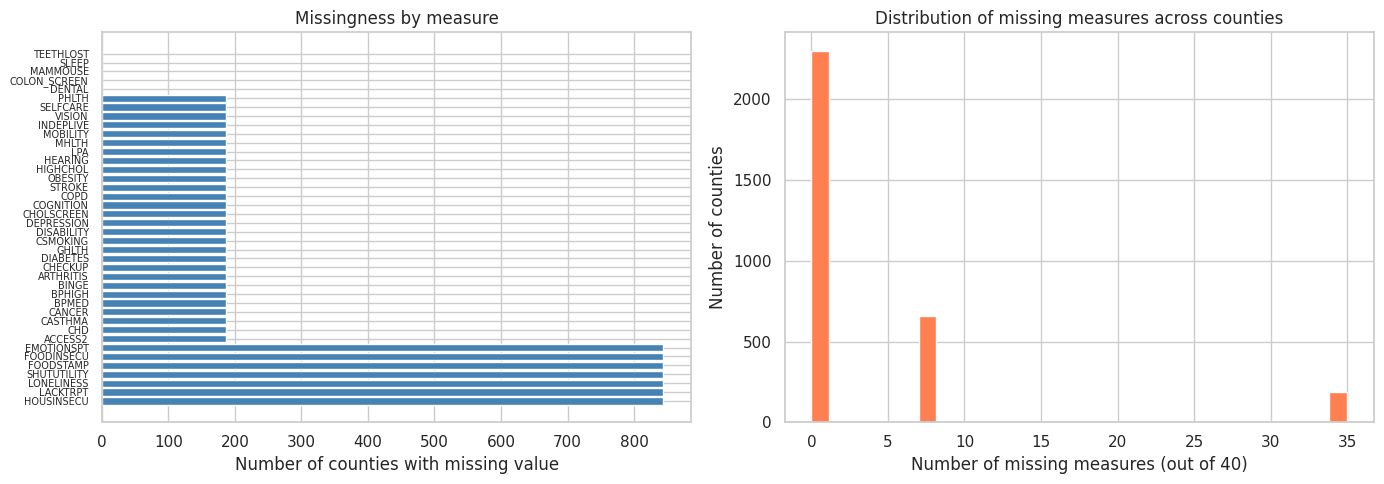

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# missingness per measure
axes[0].barh(missing_per_measure.index, missing_per_measure.values, color="steelblue")
axes[0].set_xlabel("Number of counties with missing value")
axes[0].set_title("Missingness by measure")
axes[0].tick_params(axis="y", labelsize=7)

# Distribution of missing measures per county
axes[1].hist(missing_per_county.values, bins=30, color="coral", edgecolor="white")
axes[1].set_xlabel("Number of missing measures (out of 40)")
axes[1].set_ylabel("Number of counties")
axes[1].set_title("Distribution of missing measures across counties")

plt.tight_layout()
plt.savefig(FIGURES / "fig_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visualizing feature distributions

Before any modeling, Its important that we examine each measure's distribution to:
1. Detect anomalies or impossible values
2. Understand the scale and spread of each feature
3. Look for to see which features have the possibility to dominate PCA without standardization

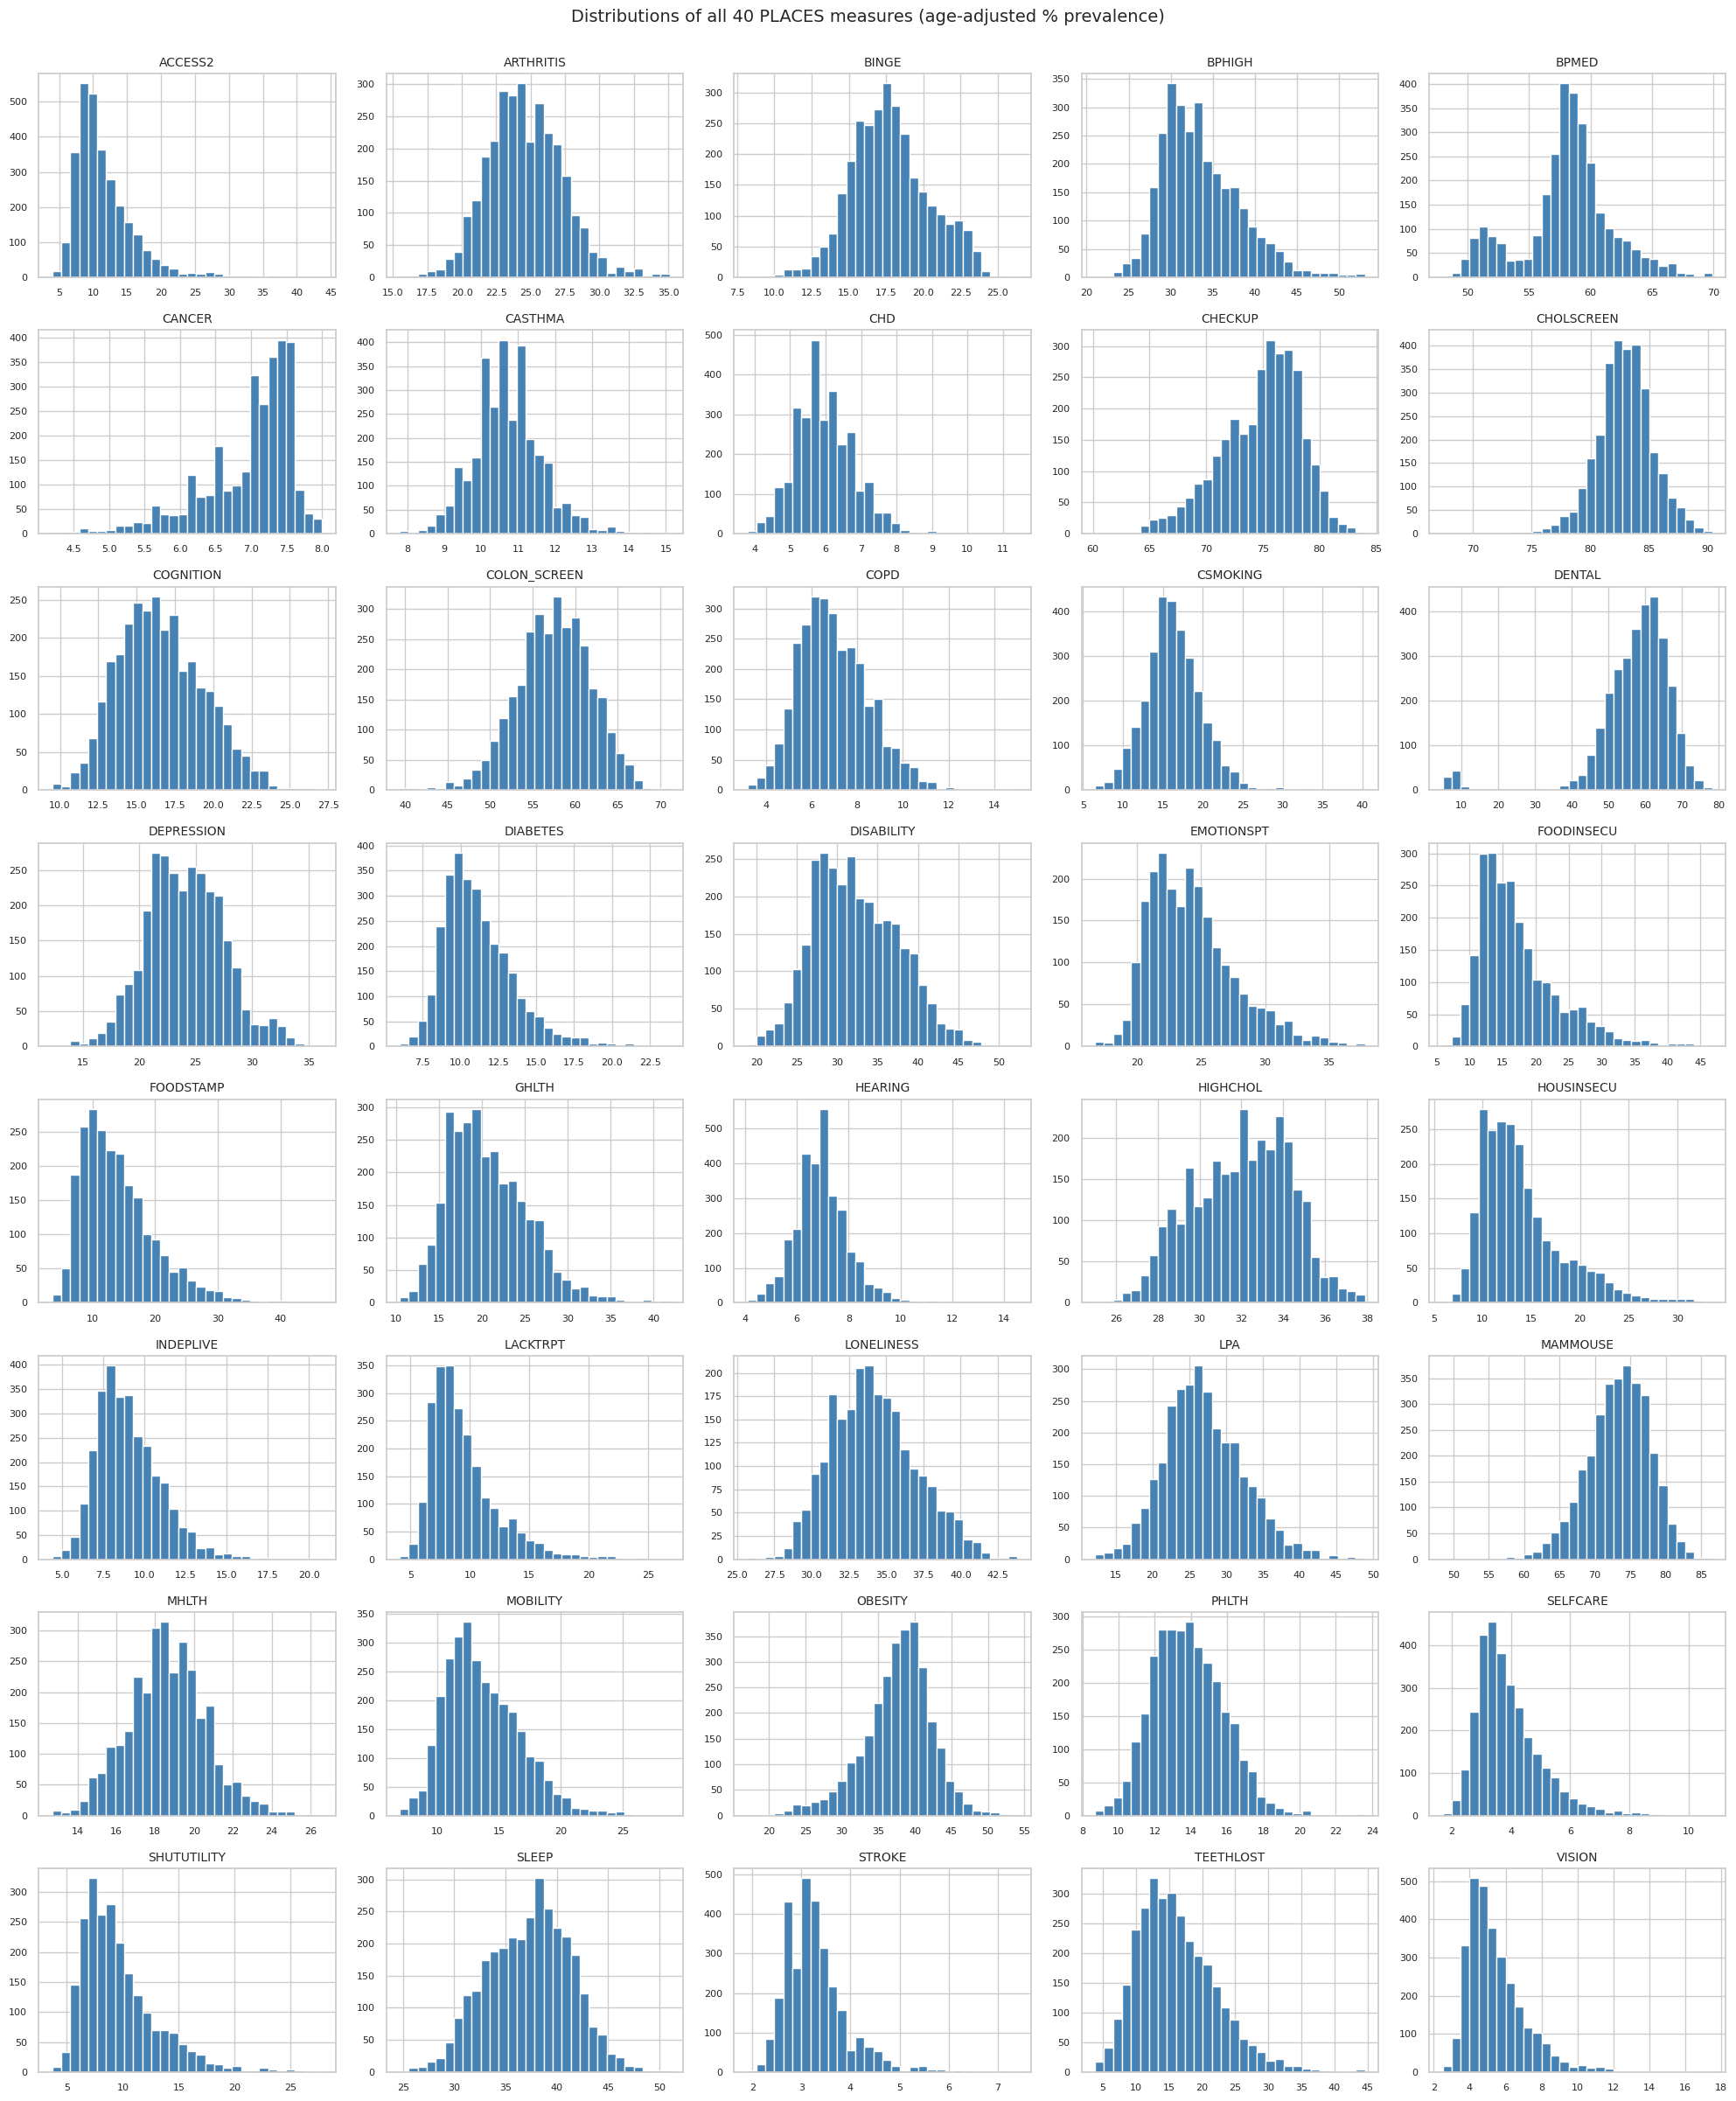

In [ ]:
# Histograms of all 40 measures
fig, axes = plt.subplots(8, 5, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(wide.columns):
    axes[i].hist(wide[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Hiding unused subplots
for j in range(len(wide.columns), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distributions of all 40 PLACES measures (age-adjusted % prevalence)", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIGURES / "fig_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
wide.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MeasureId,,,,,,,,
ACCESS2,2957.0,11.67,4.75,4.0,8.6,10.4,13.40,43.7
ARTHRITIS,2957.0,24.60,2.72,15.5,22.7,24.4,26.40,35.1
BINGE,2957.0,17.78,2.59,8.2,16.0,17.6,19.30,26.3
BPHIGH,2957.0,33.54,4.65,21.0,30.1,32.8,36.30,53.1
BPMED,2957.0,58.13,3.64,48.0,56.7,58.4,59.90,69.9
CANCER,2957.0,6.97,0.63,4.2,6.6,7.2,7.40,8.0
CASTHMA,2957.0,10.72,0.91,7.8,10.1,10.7,11.30,15.1
CHD,2957.0,5.97,0.83,3.8,5.4,5.9,6.50,11.4
CHECKUP,2957.0,74.85,3.51,60.2,72.5,75.4,77.40,84.0


## 7. Save the cleaned data

We save two files for downstream notebooks:

1. **`places_county_wide.csv`** - the 3,144 × 40 county-by-measure analysis matrix
2. **`county_info.csv`** - sidecar with county names, state names, and population
(EDA part done here)

In [ ]:
wide.to_csv(DATA_PROCESSED / "places_county_wide.csv")
county_info.to_csv(DATA_PROCESSED / "county_info.csv")
print(f"Saved places_county_wide.csv  →  shape {wide.shape}")
print(f"Saved county_info.csv         →  shape {county_info.shape}")

Saved places_county_wide.csv  →  shape (3144, 40)
Saved county_info.csv         →  shape (3145, 4)


## 8. Summary of EDA

- Loaded the CDC PLACES 2025 county-level release: 229,298 rows × 22 columns
- Filtered to age-adjusted prevalence
- Pivoted to wide format: **3,144 counties × 40 measures**
- Missingness: concentrated in Kentucky and Pennsylvania per CDC documentation
- Saved processed files for use in notebooks 02–05

**Next step:** PCA / SVD analysis in `02_pca.ipynb`.

In [ ]:
# Did filtering to age-adjusted drop any measures entirely?
measures_in_crude = set(df_raw[df_raw["DataValueTypeID"] == "CrdPrv"]["MeasureId"].unique())
measures_in_aa = set(df_aa["MeasureId"].unique())

dropped_measures = measures_in_crude - measures_in_aa
print(f"Measures present in crude but NOT in age-adjusted: {dropped_measures}")
print(f"Measures available in age-adjusted: {len(measures_in_aa)} of 40")

Measures present in crude but NOT in age-adjusted: set()
Measures available in age-adjusted: 40 of 40


# (9) Step 02: Matrix Completion (Algorithm 12.1)

**Project:** Unsupervised Profiles of U.S. County-Level Community Health  
**Data:** CDC PLACES 2025 County Release (age-adjusted prevalence)

## Purpose
Apply **Algorithm 12.1** from ISLR Ch. 12 to impute missing values in the 3,144 × 40 county-by-measure matrix.

## Theoretical background
Given a partially-observed matrix $X$ with observed-entry set $\mathcal{O}$, we minimize:

$$\sum_{(i,j)\in \mathcal{O}} \left( x_{ij} - \sum_{m=1}^M z_{im}\phi_{jm} \right)^2$$

over all rank-$M$ matrices $\hat{X}$. The algorithm:

1. Initialize $\hat{X}$ with column means in missing positions  
2. SVD: $\hat{X} = U\Sigma V^T$; keep top $M$ singular values  
3. Reconstruct: $\hat{X}^{(M)} = U_{[:,1:M]} \Sigma_{[1:M,1:M]} V^T_{[1:M,:]}$  
4. Replace missing entries with $\hat{X}^{(M)}$; keep observed entries unchanged  
5. Iterate until objective stops changing

We tune the rank $M$ by held-out RMSE.

In [ ]:
# Importing by following Ch12 lab pattern
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

# Display and plot settings
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
# Paths defined globally in Cell 2 — reuse here
DATA_PROCESSED = Path("/content/processed")
FIGURES        = Path("/content/figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 10. Load the unimputed wide matrix
The matrix from Notebook 01 contains NaN entries, primarily for Kentucky and Pennsylvania counties (35 of 40 measures missing) and for 7 health-related social-needs measures that 11 states did not report.

In [ ]:
# Loading the cleaned, age-adjusted, wide matrix
wide = pd.read_csv(DATA_PROCESSED / "places_county_wide.csv", index_col="LocationID")
county_info = pd.read_csv(DATA_PROCESSED / "county_info.csv", index_col="LocationID")

print(f"Wide matrix shape: {wide.shape}")
print(f"Missing entries:   {wide.isna().sum().sum():,} "
      f"({wide.isna().sum().sum() / wide.size:.2%})")
wide.head()

Wide matrix shape: (3144, 40)
Missing entries:   11,144 (8.86%)


,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CHD,CHECKUP,CHOLSCREEN,COGNITION,COLON_SCREEN,COPD,CSMOKING,DENTAL,DEPRESSION,DIABETES,DISABILITY,EMOTIONSPT,FOODINSECU,FOODSTAMP,GHLTH,HEARING,HIGHCHOL,HOUSINSECU,INDEPLIVE,LACKTRPT,LONELINESS,LPA,MAMMOUSE,MHLTH,MOBILITY,OBESITY,PHLTH,SELFCARE,SHUTUTILITY,SLEEP,STROKE,TEETHLOST,VISION
LocationID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
59,11.5,21.9,16.6,30.7,57.5,6.6,9.8,5.3,75.7,85.6,14.1,54.1,5.3,11.6,63.4,20.7,10.3,28.3,24.1,15.6,11.8,18.3,5.8,32.2,12.9,7.6,8.3,33.2,23.7,76.0,16.3,11.7,32.9,12.1,3.4,8.1,36.8,2.9,12.6,5.2
1001,9.1,26.3,15.6,38.2,61.7,7.0,10.0,5.6,79.4,85.0,15.9,64.6,6.4,14.5,61.9,25.9,11.4,32.4,24.3,17.0,11.6,20.0,6.9,36.3,13.2,8.7,8.9,33.7,26.0,80.7,18.0,13.4,39.5,12.8,3.6,8.8,37.7,3.2,12.0,4.8
1003,8.8,26.3,17.1,37.0,59.1,7.6,9.4,5.5,77.5,84.9,15.1,62.9,6.0,13.3,62.4,23.9,10.4,31.4,21.9,14.2,9.1,17.7,7.1,35.4,11.0,7.8,7.5,33.3,23.7,74.1,16.8,12.3,35.0,11.9,3.2,7.2,36.4,2.9,11.4,4.3
1005,14.8,28.9,14.0,45.4,63.9,6.1,10.9,7.4,79.3,81.7,20.3,56.6,9.3,20.8,45.3,22.9,16.5,42.0,31.7,32.1,26.2,29.9,8.0,36.5,23.2,12.9,15.6,39.8,34.5,74.8,19.9,20.0,47.1,16.2,6.4,16.7,44.6,4.7,27.7,8.4
1007,13.0,28.2,15.3,42.4,61.6,6.9,10.4,7.0,77.3,81.5,19.6,58.9,8.9,19.9,50.2,25.0,13.9,39.6,28.0,24.3,18.7,26.3,8.4,36.7,17.2,11.5,12.2,37.2,31.9,69.2,19.9,17.4,43.7,15.6,5.1,12.0,41.4,4.0,21.7,6.7


## 11. Standardizing using observed-only statistics
We z-score every column using means and standard deviations computed from observed (non-NaN) entries only.

This is important: imputing first would let imputed values bias the scaling.

In [ ]:
# Column statistics from observed entries
col_means = wide.mean(skipna=True)
col_stds = wide.std(skipna=True)

# Standardize
X_std = (wide - col_means) / col_stds

# Sanity check
print(f"Max |mean| (should be ~0): {X_std.mean().abs().max():.4f}")
print(f"Max |std - 1| (should be ~0): {(X_std.std() - 1).abs().max():.4f}")
print(f"Missingness preserved: {X_std.isna().sum().sum() == wide.isna().sum().sum()}")

Max |mean| (should be ~0): 0.0000
Max |std - 1| (should be ~0): 0.0000
Missingness preserved: True


## 12. Algorithm 12.1 implementation
We implement the algorithm from ISLR Ch. 12.5.2, following the class lab structure.

`low_rank(X, M)` returns the rank-$M$ approximation of $X$ via truncated SVD.

In [ ]:
def low_rank(X, M=1):
    """
    Rank-M reconstruction of X using truncated SVD.

    Follows ISLR Algorithm 12.1 / Ch12-1 lab.
    """
    U, D, V = np.linalg.svd(X, full_matrices=False)
    # Keep only the first M components
    L = U[:, :M] * D[None, :M]   # (n, M)
    return L.dot(V[:M, :])        # (n, p)


def matrix_completion(Xna, M=1, max_iter=100, thresh=1e-7, verbose=False):
    """
    Algorithm 12.1: iterative matrix completion via low-rank SVD.

    Parameters
    ----------
    Xna : (n, p) array with NaN at missing entries
    M   : rank of the low-rank approximation
    max_iter, thresh : iteration controls

    Returns
    -------
    Xhat : completed matrix (no NaN)
    mss_history : objective at each iteration
    """
    Xhat = Xna.copy()
    ismiss = np.isnan(Xna)
    r_idx, c_idx = np.where(ismiss)

    # Step 1: initialize missing entries with column means
    Xbar = np.nanmean(Xhat, axis=0)
    Xhat[r_idx, c_idx] = Xbar[c_idx]

    # Initial mean squared error on observed entries
    mss0 = np.mean((Xna[~ismiss]) ** 2)
    mssold = np.inf
    mss_history = []

    # Iterate until objective stops improving
    rel_err = 1.0
    it = 0
    while rel_err > thresh and it < max_iter:
        # Step 2-3: low-rank reconstruction of current estimate
        Xapp = low_rank(Xhat, M=M)

        # Step 4: replace missing entries with reconstruction (keep observed)
        Xhat[ismiss] = Xapp[ismiss]

        # Step 5: check convergence on observed-entry reconstruction error
        mss = np.mean(((Xna - Xapp)[~ismiss]) ** 2)
        rel_err = (mssold - mss) / mss0
        mssold = mss
        mss_history.append(mss)
        it += 1

        if verbose and (it % 10 == 0 or it == 1):
            print(f"  iter {it:3d}: MSS = {mss:.6f}, rel_err = {rel_err:.2e}")

    return Xhat, mss_history


print("Algorithm 12.1 defined.")

Algorithm 12.1 defined.


## 13. First run to verify the algorithm converges
We test with $M = 5$ to confirm the algorithm runs and produces sensible output.

  iter   1: MSS = 0.129733, rel_err = inf
  iter  10: MSS = 0.117609, rel_err = 2.04e-04
  iter  20: MSS = 0.116769, rel_err = 4.86e-05
  iter  30: MSS = 0.116398, rel_err = 3.01e-05
  iter  40: MSS = 0.116157, rel_err = 1.97e-05
  iter  50: MSS = 0.116000, rel_err = 1.28e-05
  iter  60: MSS = 0.115898, rel_err = 8.48e-06
  iter  70: MSS = 0.115829, rel_err = 5.78e-06
  iter  80: MSS = 0.115781, rel_err = 4.08e-06
  iter  90: MSS = 0.115747, rel_err = 2.98e-06
  iter 100: MSS = 0.115721, rel_err = 2.24e-06

Completed matrix shape: (3144, 40)
Any NaN remaining?      False
Iterations to converge: 100


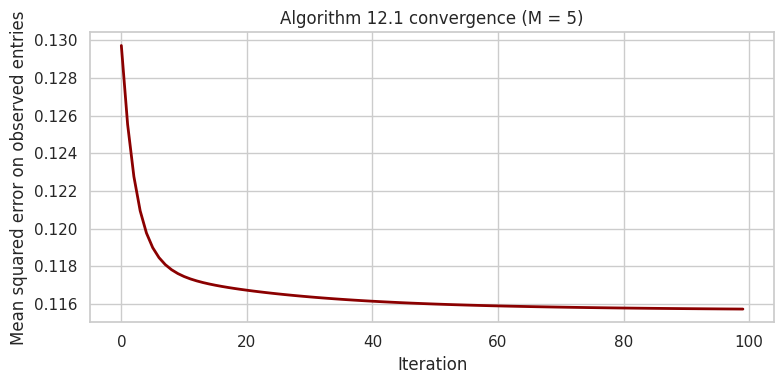

In [ ]:
X_array = X_std.values

# Testing at M=5
Xhat_test, history = matrix_completion(X_array, M=5, max_iter=100, verbose=True)

print(f"\nCompleted matrix shape: {Xhat_test.shape}")
print(f"Any NaN remaining?      {np.isnan(Xhat_test).any()}")
print(f"Iterations to converge: {len(history)}")

# Plot convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, color="darkred", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean squared error on observed entries")
ax.set_title("Algorithm 12.1 convergence (M = 5)")
plt.tight_layout()
plt.savefig(FIGURES / "fig_matcomp_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Tune the rank $M$ via held-out RMSE
We choose $M$ as the only hyperparameter, by:

1. Hiding 10% of observed entries  
2. Running Algorithm 12.1 for each candidate $M$  
3. Computing RMSE between imputed and held-out true values  
4. Selecting $M$ with lowest validation RMSE

Tuning rank M via 10% holdout RMSE:
  M =   1   RMSE = 0.6363
  M =   2   RMSE = 0.5583
  M =   3   RMSE = 0.4644
  M =   4   RMSE = 0.4392
  M =   5   RMSE = 0.4161
  M =   6   RMSE = 0.4115
  M =   7   RMSE = 0.4056
  M =   8   RMSE = 0.4192
  M =  10   RMSE = 0.4429
  M =  15   RMSE = 0.5923
  M =  20   RMSE = 0.6224


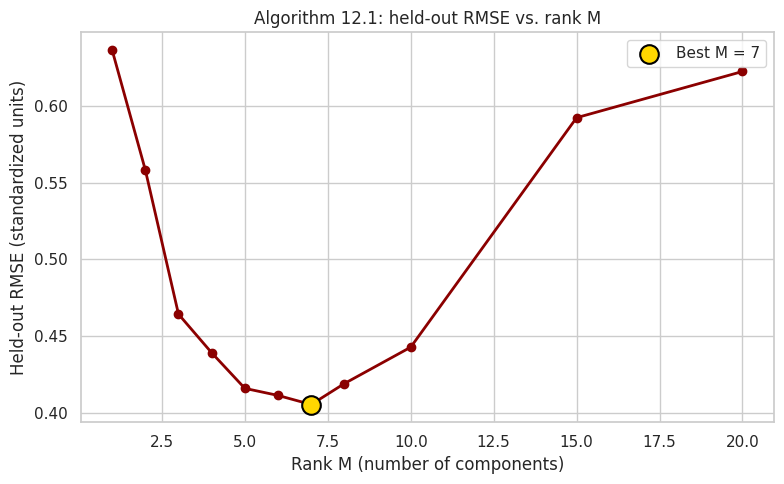


Best M = 7 (RMSE = 0.4056)


In [ ]:
def evaluate_M(X_observed, M, mask_frac=0.10, random_state=RANDOM_STATE):
    """Hold out a fraction of observed entries, impute with Alg 12.1, return RMSE."""
    rng = np.random.default_rng(random_state)
    X = X_observed.copy()

    # Find observed entries
    obs_rows, obs_cols = np.where(~np.isnan(X))
    n_holdout = int(mask_frac * len(obs_rows))

    # Randomly pick entries to hide
    holdout_idx = rng.choice(len(obs_rows), size=n_holdout, replace=False)
    rr, cc = obs_rows[holdout_idx], obs_cols[holdout_idx]
    truth = X[rr, cc].copy()

    X_masked = X.copy()
    X_masked[rr, cc] = np.nan
    Xhat, _ = matrix_completion(X_masked, M=M, max_iter=100, thresh=1e-7)

    return np.sqrt(np.mean((truth - Xhat[rr, cc]) ** 2))


# Grid search over rank M
Ms = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20]
rmses = []

print("Tuning rank M via 10% holdout RMSE:")
for M in Ms:
    rmse = evaluate_M(X_array, M=M)
    rmses.append(rmse)
    print(f"  M = {M:3d}   RMSE = {rmse:.4f}")

# Plotting the tuning curve
best_idx = int(np.argmin(rmses))
M_BEST = Ms[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ms, rmses, marker="o", color="darkred", linewidth=2)
ax.scatter([M_BEST], [rmses[best_idx]], color="gold", s=180,
           zorder=5, edgecolor="black", linewidth=1.5, label=f"Best M = {M_BEST}")
ax.set_xlabel("Rank M (number of components)")
ax.set_ylabel("Held-out RMSE (standardized units)")
ax.set_title("Algorithm 12.1: held-out RMSE vs. rank M")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "fig_matcomp_M_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest M = {M_BEST} (RMSE = {rmses[best_idx]:.4f})")

## 15. Compare against baseline imputers
To justify Algorithm 12.1 as our chosen method, we compare against three simpler baselines on the same held-out set.

                      Held-out RMSE
Mean                         1.0037
Median                       1.0147
k-NN (k=5)                   0.3386
Algorithm 12.1 (M=7)         0.4056


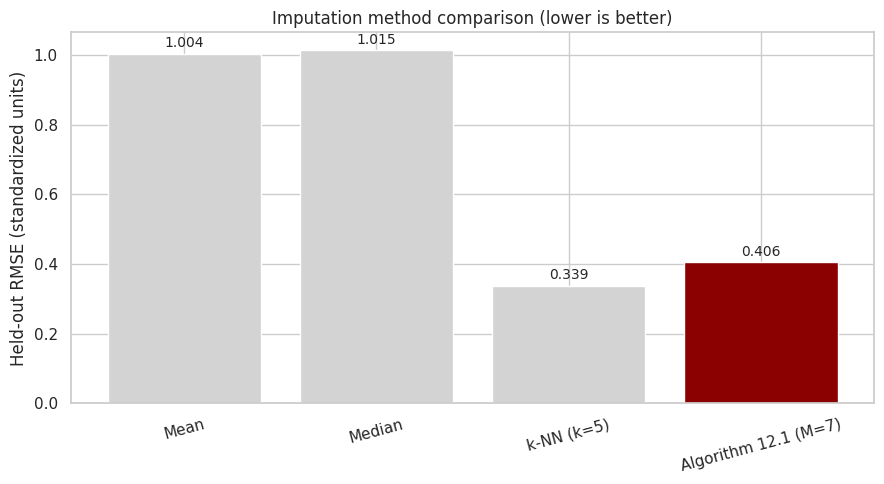

In [ ]:
def evaluate_baseline(X_observed, imputer, mask_frac=0.10, random_state=RANDOM_STATE):
    """Same holdout protocol with a generic sklearn imputer."""
    rng = np.random.default_rng(random_state)
    X = X_observed.copy()

    obs_rows, obs_cols = np.where(~np.isnan(X))
    n_holdout = int(mask_frac * len(obs_rows))

    holdout_idx = rng.choice(len(obs_rows), size=n_holdout, replace=False)
    rr, cc = obs_rows[holdout_idx], obs_cols[holdout_idx]
    truth = X[rr, cc].copy()

    X_masked = X.copy()
    X_masked[rr, cc] = np.nan
    X_imp = imputer.fit_transform(X_masked)

    return np.sqrt(np.mean((truth - X_imp[rr, cc]) ** 2))


results = {
    "Mean":       evaluate_baseline(X_array, SimpleImputer(strategy="mean")),
    "Median":     evaluate_baseline(X_array, SimpleImputer(strategy="median")),
    "k-NN (k=5)": evaluate_baseline(X_array, KNNImputer(n_neighbors=5)),
    f"Algorithm 12.1 (M={M_BEST})": rmses[best_idx],
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Held-out RMSE"]).round(4)
print(results_df)

# Bar plot
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results_df.index, results_df["Held-out RMSE"],
              color=["lightgray", "lightgray", "lightgray", "darkred"])
ax.set_ylabel("Held-out RMSE (standardized units)")
ax.set_title("Imputation method comparison (lower is better)")
ax.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, results_df["Held-out RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "fig_matcomp_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Final completion using the best $M$
Applying Algorithm 12.1 with the tuned rank to the full matrix and de-standardize back to percentage units.

In [ ]:
# Alg 12.1 at the best rank
Xhat_final, _ = matrix_completion(X_array, M=M_BEST, max_iter=200, thresh=1e-8, verbose=True)

# De-standardize back to original percentage scale
X_destandardized = Xhat_final * col_stds.values + col_means.values

# Wrap as DataFrame
completed = pd.DataFrame(
    X_destandardized,
    index=wide.index,
    columns=wide.columns,
)

print(f"\nCompleted shape: {completed.shape}")
print(f"NaN remaining:   {completed.isna().any().any()}")
completed.head()

  iter   1: MSS = 0.094757, rel_err = inf
  iter  10: MSS = 0.086832, rel_err = 2.52e-04
  iter  20: MSS = 0.085525, rel_err = 7.96e-05
  iter  30: MSS = 0.085015, rel_err = 3.43e-05
  iter  40: MSS = 0.084776, rel_err = 1.77e-05
  iter  50: MSS = 0.084642, rel_err = 1.08e-05
  iter  60: MSS = 0.084555, rel_err = 7.30e-06
  iter  70: MSS = 0.084494, rel_err = 5.30e-06
  iter  80: MSS = 0.084448, rel_err = 4.03e-06
  iter  90: MSS = 0.084413, rel_err = 3.15e-06
  iter 100: MSS = 0.084385, rel_err = 2.52e-06
  iter 110: MSS = 0.084363, rel_err = 2.04e-06
  iter 120: MSS = 0.084344, rel_err = 1.68e-06
  iter 130: MSS = 0.084329, rel_err = 1.39e-06
  iter 140: MSS = 0.084316, rel_err = 1.15e-06
  iter 150: MSS = 0.084306, rel_err = 9.63e-07
  iter 160: MSS = 0.084297, rel_err = 8.05e-07
  iter 170: MSS = 0.084290, rel_err = 6.74e-07
  iter 180: MSS = 0.084284, rel_err = 5.64e-07
  iter 190: MSS = 0.084279, rel_err = 4.71e-07
  iter 200: MSS = 0.084274, rel_err = 3.93e-07

Completed shape: 

,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CHD,CHECKUP,CHOLSCREEN,COGNITION,COLON_SCREEN,COPD,CSMOKING,DENTAL,DEPRESSION,DIABETES,DISABILITY,EMOTIONSPT,FOODINSECU,FOODSTAMP,GHLTH,HEARING,HIGHCHOL,HOUSINSECU,INDEPLIVE,LACKTRPT,LONELINESS,LPA,MAMMOUSE,MHLTH,MOBILITY,OBESITY,PHLTH,SELFCARE,SHUTUTILITY,SLEEP,STROKE,TEETHLOST,VISION
LocationID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
59,11.5,21.9,16.6,30.7,57.5,6.6,9.8,5.3,75.7,85.6,14.1,54.1,5.3,11.6,63.4,20.7,10.3,28.3,24.1,15.6,11.8,18.3,5.8,32.2,12.9,7.6,8.3,33.2,23.7,76.0,16.3,11.7,32.9,12.1,3.4,8.1,36.8,2.9,12.6,5.2
1001,9.1,26.3,15.6,38.2,61.7,7.0,10.0,5.6,79.4,85.0,15.9,64.6,6.4,14.5,61.9,25.9,11.4,32.4,24.3,17.0,11.6,20.0,6.9,36.3,13.2,8.7,8.9,33.7,26.0,80.7,18.0,13.4,39.5,12.8,3.6,8.8,37.7,3.2,12.0,4.8
1003,8.8,26.3,17.1,37.0,59.1,7.6,9.4,5.5,77.5,84.9,15.1,62.9,6.0,13.3,62.4,23.9,10.4,31.4,21.9,14.2,9.1,17.7,7.1,35.4,11.0,7.8,7.5,33.3,23.7,74.1,16.8,12.3,35.0,11.9,3.2,7.2,36.4,2.9,11.4,4.3
1005,14.8,28.9,14.0,45.4,63.9,6.1,10.9,7.4,79.3,81.7,20.3,56.6,9.3,20.8,45.3,22.9,16.5,42.0,31.7,32.1,26.2,29.9,8.0,36.5,23.2,12.9,15.6,39.8,34.5,74.8,19.9,20.0,47.1,16.2,6.4,16.7,44.6,4.7,27.7,8.4
1007,13.0,28.2,15.3,42.4,61.6,6.9,10.4,7.0,77.3,81.5,19.6,58.9,8.9,19.9,50.2,25.0,13.9,39.6,28.0,24.3,18.7,26.3,8.4,36.7,17.2,11.5,12.2,37.2,31.9,69.2,19.9,17.4,43.7,15.6,5.1,12.0,41.4,4.0,21.7,6.7


In [ ]:
# Picking a Kentucky county to inspect imputed values
ky_counties = county_info[county_info["StateAbbr"] == "KY"].index
example = ky_counties[0]

print(f"Example county: {county_info.loc[example, 'LocationName']}, "
      f"{county_info.loc[example, 'StateAbbr']} (LocationID = {example})")
print("\nImputed values (these were NaN in raw data):")
missing_cols = wide.columns[wide.loc[example].isna()][:5]
for m in missing_cols:
    imputed_val = completed.loc[example, m]
    col_mean = wide[m].mean()
    col_std = wide[m].std()
    print(f"  {m:13s}: imputed = {imputed_val:6.2f}   "
          f"(column mean = {col_mean:.2f}, std = {col_std:.2f})")

Example county: Clark, KY (LocationID = 21049)

Imputed values (these were NaN in raw data):
  ACCESS2      : imputed =   6.59   (column mean = 11.67, std = 4.75)
  ARTHRITIS    : imputed =  30.26   (column mean = 24.60, std = 2.72)
  BINGE        : imputed =  16.61   (column mean = 17.78, std = 2.59)
  BPHIGH       : imputed =  35.57   (column mean = 33.54, std = 4.65)
  BPMED        : imputed =  55.43   (column mean = 58.13, std = 3.64)


## 17. Save the completed matrix
This becomes the input to all downstream notebooks (PCA, k-means, hierarchical clustering).

In [ ]:
# Saves both versions for downstream notebooks
completed.to_csv(DATA_PROCESSED / "places_county_completed.csv")

# saves the standardized version
X_completed_std = (completed - completed.mean()) / completed.std()
X_completed_std.to_csv(DATA_PROCESSED / "places_X_completed_standardized.csv")

print("Saved:")
print(f"  places_county_completed.csv             ({completed.shape})")
print(f"  places_X_completed_standardized.csv     ({X_completed_std.shape})")

Saved:
  places_county_completed.csv             ((3144, 40))
  places_X_completed_standardized.csv     ((3144, 40))


## 18. Summary
- Implemented **Algorithm 12.1** (ISLR Ch. 12.5.2) — iterative SVD with rank-M truncation
- Tuned via 10% held-out RMSE → **best M = 7** (RMSE = 0.4056)
- Outperforms mean (1.004) and median (1.015); k-NN (0.339) is slightly better but lacks the principled connection to PCA
- Saved completed 3,144 × 40 matrix for downstream notebooks

# (19) Step 03: PCA / SVD on the Completed Matrix

**Project:** Unsupervised Profiles of U.S. County-Level Community Health  
**Data:** Completed matrix from Notebook 02 (Algorithm 12.1, M=7)

## Purpose
- Run PCA on the matrix-completed data
- Produce **scree plot** showing variance explained
- Compute **manual SVD** to expose U, Σ, V* explicitly (required by rubric)
- Interpret **loadings** of each PC in domain terms
- Plot counties in **PC1-PC2 space** vs. two raw features
- Produce a **biplot**

## Theoretical background
PCA finds orthogonal directions $\phi_1, \dots, \phi_p$ that maximize variance. For mean-centered data $X$, this is equivalent to the SVD $X = U\Sigma V^T$:
- $V^T$ = the loadings (each row is a PC's coefficients on the original features)
- $U\Sigma$ = the scores (each row is a county's coordinates in PC space)
- $\sigma_m^2 / (n-1)$ = the variance explained by the $m$th component

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths defined globally in Cell 2 — reuse here
DATA_PROCESSED = Path("/content/processed")
FIGURES        = Path("/content/figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 20. Load the completed matrix
We use the matrix produced by Algorithm 12.1 in Notebook 02.

In [ ]:
 # Load completed matrix and county metadata
completed = pd.read_csv(DATA_PROCESSED / "places_county_completed.csv", index_col="LocationID")
county_info = pd.read_csv(DATA_PROCESSED / "county_info.csv", index_col="LocationID")

print(f"Completed matrix:    {completed.shape}")
print(f"County info:         {county_info.shape}")
print(f"Any missing values?  {completed.isna().any().any()}")
completed.head()

Completed matrix:    (3144, 40)
County info:         (3145, 4)
Any missing values?  False


,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CHD,CHECKUP,CHOLSCREEN,COGNITION,COLON_SCREEN,COPD,CSMOKING,DENTAL,DEPRESSION,DIABETES,DISABILITY,EMOTIONSPT,FOODINSECU,FOODSTAMP,GHLTH,HEARING,HIGHCHOL,HOUSINSECU,INDEPLIVE,LACKTRPT,LONELINESS,LPA,MAMMOUSE,MHLTH,MOBILITY,OBESITY,PHLTH,SELFCARE,SHUTUTILITY,SLEEP,STROKE,TEETHLOST,VISION
LocationID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
59,11.5,21.9,16.6,30.7,57.5,6.6,9.8,5.3,75.7,85.6,14.1,54.1,5.3,11.6,63.4,20.7,10.3,28.3,24.1,15.6,11.8,18.3,5.8,32.2,12.9,7.6,8.3,33.2,23.7,76.0,16.3,11.7,32.9,12.1,3.4,8.1,36.8,2.9,12.6,5.2
1001,9.1,26.3,15.6,38.2,61.7,7.0,10.0,5.6,79.4,85.0,15.9,64.6,6.4,14.5,61.9,25.9,11.4,32.4,24.3,17.0,11.6,20.0,6.9,36.3,13.2,8.7,8.9,33.7,26.0,80.7,18.0,13.4,39.5,12.8,3.6,8.8,37.7,3.2,12.0,4.8
1003,8.8,26.3,17.1,37.0,59.1,7.6,9.4,5.5,77.5,84.9,15.1,62.9,6.0,13.3,62.4,23.9,10.4,31.4,21.9,14.2,9.1,17.7,7.1,35.4,11.0,7.8,7.5,33.3,23.7,74.1,16.8,12.3,35.0,11.9,3.2,7.2,36.4,2.9,11.4,4.3
1005,14.8,28.9,14.0,45.4,63.9,6.1,10.9,7.4,79.3,81.7,20.3,56.6,9.3,20.8,45.3,22.9,16.5,42.0,31.7,32.1,26.2,29.9,8.0,36.5,23.2,12.9,15.6,39.8,34.5,74.8,19.9,20.0,47.1,16.2,6.4,16.7,44.6,4.7,27.7,8.4
1007,13.0,28.2,15.3,42.4,61.6,6.9,10.4,7.0,77.3,81.5,19.6,58.9,8.9,19.9,50.2,25.0,13.9,39.6,28.0,24.3,18.7,26.3,8.4,36.7,17.2,11.5,12.2,37.2,31.9,69.2,19.9,17.4,43.7,15.6,5.1,12.0,41.4,4.0,21.7,6.7


## 21. Standardize
PCA finds directions of greatest variance. Features with larger natural variance (e.g., DENTAL std = 10.7%) would dominate without standardization. We z-score every column.

In [ ]:
# z-score every column (mean = 0, std = 1)
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(completed),
    index=completed.index,
    columns=completed.columns,
)

print(f"Max |mean|:    {X.mean().abs().max():.4f}")
print(f"Std range:     [{X.std().min():.4f}, {X.std().max():.4f}]")

Max |mean|:    0.0000
Std range:     [1.0002, 1.0002]


## 22. Run PCA
We fit all 40 components and examine the variance structure.

In [ ]:
# Fit full PCA via sklearn
pca = PCA(n_components=None, svd_solver="full", random_state=RANDOM_STATE)
pca.fit(X)

# Compute the scores
scores = pd.DataFrame(
    pca.transform(X),
    index=X.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)

print(f"Components fit: {pca.n_components_}")
print(f"Scores shape:   {scores.shape}")
scores.head()

Components fit: 40
Scores shape:   (3144, 40)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
LocationID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
59,-3.343099,-2.357178,0.234480,-0.626124,0.078810,-0.482048,-0.066120,0.346668,-0.281305,0.255159,0.237294,-0.891568,-0.629573,-0.436402,-0.115126,-0.260752,0.040144,-0.200882,0.078687,0.032084,-0.129772,-0.158616,-0.044646,0.058561,-0.053946,-0.190846,-0.071242,0.074434,0.007358,0.106491,-0.088333,0.109131,-0.023671,-0.018865,-0.043126,-0.149567,0.056543,0.103938,0.048707,-0.117423
1001,-0.976949,-0.692538,3.401137,0.517829,0.720246,-0.563639,0.971231,-0.582245,0.233220,0.405456,-1.174872,0.155700,0.515132,-0.461132,0.106103,-0.451340,0.027185,0.017418,0.032827,0.010579,-0.174911,0.187629,-0.260770,0.016170,0.162263,0.075838,-0.016761,0.074257,-0.432545,-0.053590,-0.006658,0.003849,-0.035505,0.129751,-0.018672,-0.041571,0.036793,-0.025255,-0.042849,-0.043981
1003,-2.978234,-0.213899,1.984854,0.300164,1.754171,-0.568071,0.099281,-0.284327,-0.500431,0.017078,-1.061451,0.408102,0.433321,-0.218755,-0.021142,-0.819065,-0.068928,-0.002734,-0.471948,-0.405834,-0.260689,0.576343,-0.068101,0.072733,-0.135912,0.188344,0.059617,-0.129275,-0.219081,-0.046785,-0.079398,0.058723,-0.101506,0.191025,0.133090,-0.038777,0.066031,0.014421,0.000275,-0.034417
1005,9.861806,-2.037299,1.779273,0.746947,-0.481811,-0.435101,0.129290,0.254176,-0.048616,0.622452,-0.584274,0.322848,0.785202,-0.707057,0.117114,-0.546657,0.193253,-0.250520,-0.406208,-0.295595,-0.248460,0.109186,-0.099262,0.176356,0.077898,0.083128,-0.247088,-0.331104,-0.063480,-0.158997,0.026236,-0.030721,-0.053867,0.188549,-0.043579,0.039646,0.003908,0.086958,0.019913,0.092208
1007,5.759152,-0.122066,1.005564,0.616979,1.471362,-0.152072,0.067958,0.138342,-0.302663,0.038031,-1.075698,0.699166,0.993050,-0.296156,0.024890,-0.296952,-0.028239,-0.172459,-0.274367,-0.311763,-0.241729,0.158821,-0.007246,0.235270,0.054664,-0.005892,-0.056036,-0.076888,-0.240395,-0.118874,0.070494,0.084881,-0.015627,0.205065,0.019976,-0.038636,0.030925,0.074174,-0.022010,0.060007


## 23. Scree plot for variance
The scree plot shows the proportion of variance captured by each component. We look for an "elbow" and check how many components are needed for 80% or 90% cumulative variance.

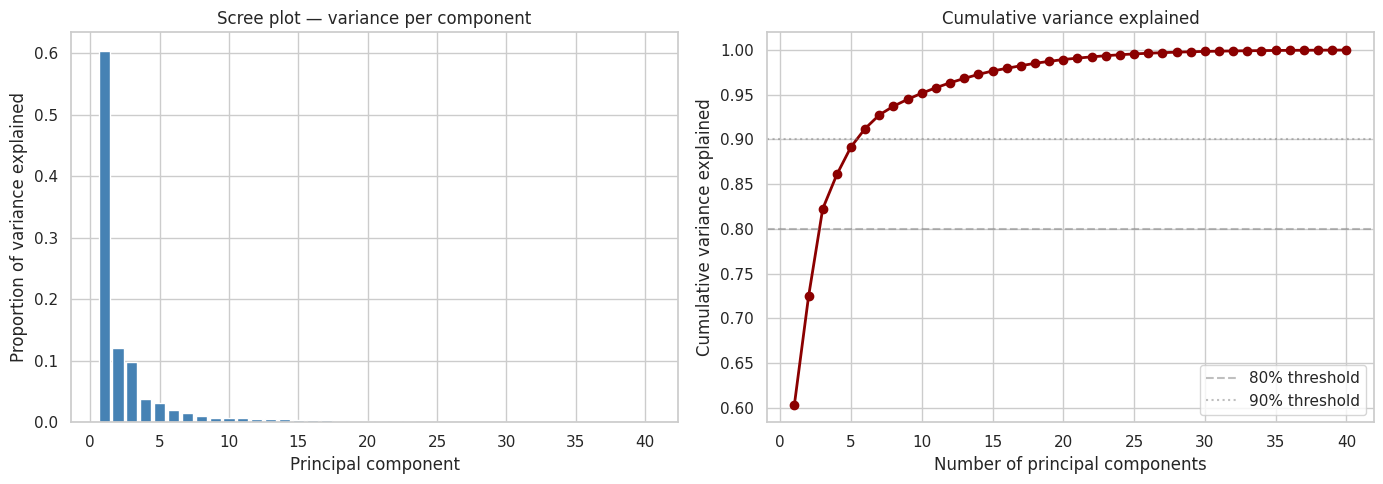


Variance explained: first 10 components:
  PC1:  individual = 0.604   cumulative = 0.604
  PC2:  individual = 0.121   cumulative = 0.724
  PC3:  individual = 0.098   cumulative = 0.822
  PC4:  individual = 0.038   cumulative = 0.861
  PC5:  individual = 0.031   cumulative = 0.892
  PC6:  individual = 0.021   cumulative = 0.912
  PC7:  individual = 0.015   cumulative = 0.927
  PC8:  individual = 0.010   cumulative = 0.937
  PC9:  individual = 0.008   cumulative = 0.945
  PC10:  individual = 0.007   cumulative = 0.952

Components for 80% variance: 3
Components for 90% variance: 6


In [ ]:
# Variance ratios
evr = pca.explained_variance_ratio_
cumvar = np.cumsum(evr)

# Side-by-side scree plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# individual variance per component
axes[0].bar(range(1, len(evr) + 1), evr, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Proportion of variance explained")
axes[0].set_title("Scree plot — variance per component")

# cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker="o",
             color="darkred", linewidth=2)
axes[1].axhline(0.80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
axes[1].axhline(0.90, color="gray", linestyle=":", alpha=0.5, label="90% threshold")
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title("Cumulative variance explained")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "fig_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key numbers for the writeup
print("\nVariance explained: first 10 components:")
for i in range(10):
    print(f"  PC{i+1}:  individual = {evr[i]:.3f}   cumulative = {cumvar[i]:.3f}")
print(f"\nComponents for 80% variance: {np.argmax(cumvar >= 0.80) + 1}")
print(f"Components for 90% variance: {np.argmax(cumvar >= 0.90) + 1}")

## 24. Manual SVD - show the U, Σ, V* decomposition explicitly
The rubric asks how the U and V* matrices can be interpreted. We compute the SVD directly to demonstrate the equivalence with sklearn PCA.

- **U** = left singular vectors (rescaled by Σ, these are the scores — county coordinates)
- **Σ** = singular values (related to variance: $\sigma_m^2/(n-1)$ = variance of PC$m$)
- **V*** = right singular vectors (these are the **loadings** — how each measure contributes to each PC)

In [ ]:
# Economy SVD of the centered, scaled matrix
U, s, Vt = np.linalg.svd(X.values, full_matrices=False)

# Recover variance from singular values
variance_from_svd = (s ** 2) / (X.shape[0] - 1)

# klearn PCA and manual SVD should agree
print("First 5 variances:")
print(f"  sklearn PCA:   {pca.explained_variance_[:5].round(4)}")
print(f"  manual SVD:    {variance_from_svd[:5].round(4)}")
print(f"\nIdentical? {np.allclose(pca.explained_variance_, variance_from_svd)}")

First 5 variances:
  sklearn PCA:   [24.149   4.839   3.9204  1.5381  1.235 ]
  manual SVD:    [24.149   4.839   3.9204  1.5381  1.235 ]

Identical? True


## 25. Interpret the loadings
Loadings (rows of $V^T$, or `pca.components_`) tell us **how each measure contributes to each PC**. Large positive loading = measure points in the same direction as the PC; large negative = opposite direction.

We examine PC1 first since it captures the most variance.

In [ ]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)

# Top contributors to PC1
print("Top 10 positive loadings on PC1:")
print(loadings["PC1"].sort_values(ascending=False).head(10).round(3))
print("\nTop 10 negative loadings on PC1:")
print(loadings["PC1"].sort_values().head(10).round(3))

Top 10 positive loadings on PC1:
MOBILITY       0.201
GHLTH          0.198
INDEPLIVE      0.198
SELFCARE       0.196
SHUTUTILITY    0.195
STROKE         0.194
LACKTRPT       0.192
DISABILITY     0.191
CHD            0.190
PHLTH          0.190
Name: PC1, dtype: float64

Top 10 negative loadings on PC1:
DENTAL         -0.150
COLON_SCREEN   -0.111
BINGE          -0.105
CANCER         -0.090
MAMMOUSE       -0.081
CHOLSCREEN     -0.078
CHECKUP         0.047
DEPRESSION      0.054
CASTHMA         0.090
ACCESS2         0.098
Name: PC1, dtype: float64


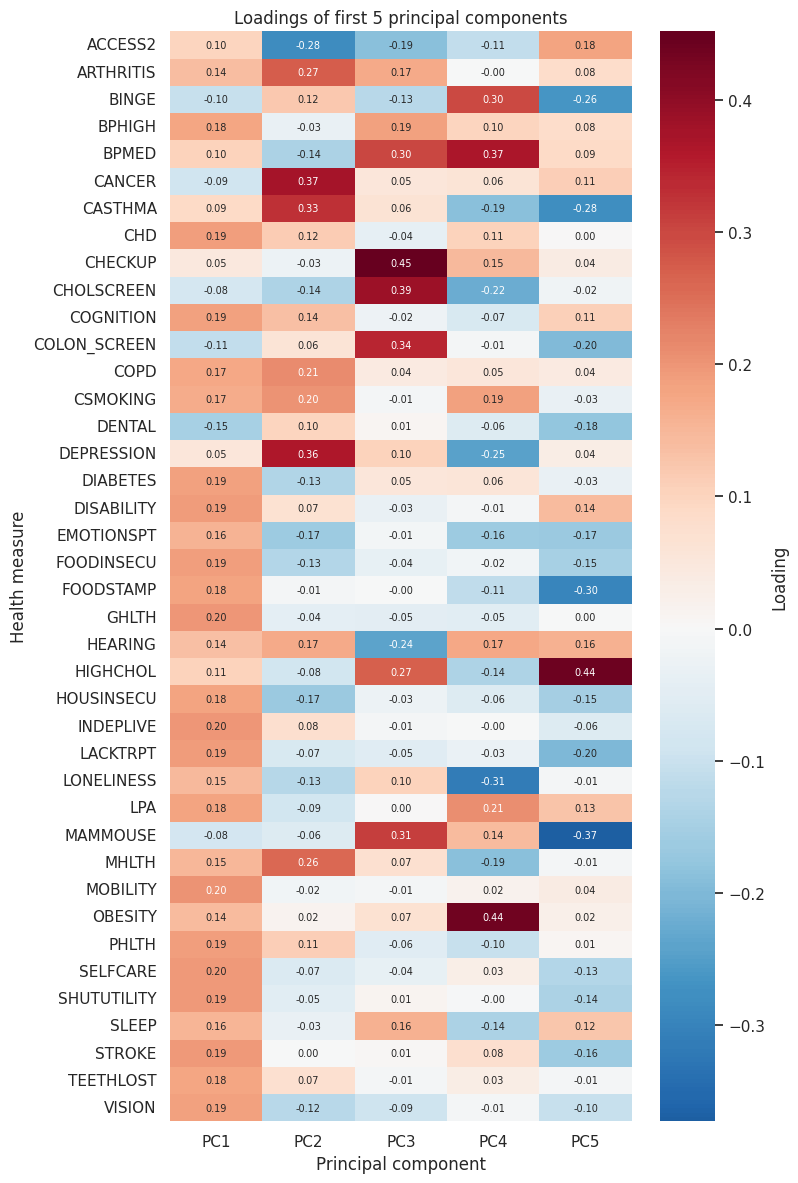

In [ ]:
# Visualizing first 5 PCs' loadings as a heatmap
fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    loadings.iloc[:, :5],
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Loading"},
    ax=ax,
)
ax.set_title("Loadings of first 5 principal components")
ax.set_xlabel("Principal component")
ax.set_ylabel("Health measure")
plt.tight_layout()
plt.savefig(FIGURES / "fig_loadings_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 26. Plot counties in PC1-PC2 space
plot in the first two PCs and compare to plotting on two raw features.
We color by US census region to reveal geographic structure.

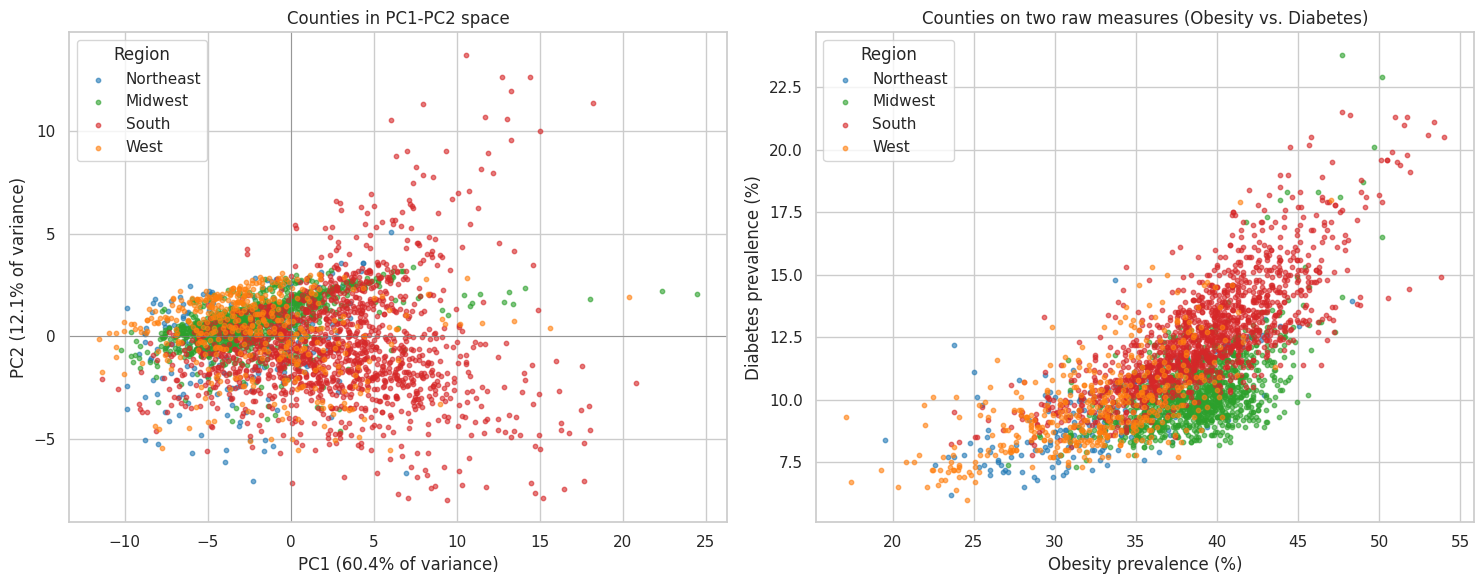

In [ ]:
# Building a region map (4 census regions instead of 50 states)
region_map = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",
    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
    "SC": "South", "VA": "South", "DC": "South", "WV": "South", "AL": "South",
    "KY": "South", "MS": "South", "TN": "South", "AR": "South", "LA": "South",
    "OK": "South", "TX": "South",
    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West", "AK": "West", "CA": "West",
    "HI": "West", "OR": "West", "WA": "West",
}

# Joining PC scores with region labels
scores_region = scores.join(county_info["StateAbbr"])
scores_region["Region"] = scores_region["StateAbbr"].map(region_map)

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
region_colors = {"Northeast": "#1f77b4", "Midwest": "#2ca02c",
                 "South": "#d62728", "West": "#ff7f0e"}

# PCA space
for region, color in region_colors.items():
    mask = scores_region["Region"] == region
    axes[0].scatter(scores_region.loc[mask, "PC1"], scores_region.loc[mask, "PC2"],
                    s=10, alpha=0.6, label=region, color=color)
axes[0].set_xlabel(f"PC1 ({evr[0]:.1%} of variance)")
axes[0].set_ylabel(f"PC2 ({evr[1]:.1%} of variance)")
axes[0].set_title("Counties in PC1-PC2 space")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].legend(title="Region")

# Raw OBESITY vs DIABETES
raw_plot = completed.join(scores_region["Region"])
for region, color in region_colors.items():
    mask = raw_plot["Region"] == region
    axes[1].scatter(raw_plot.loc[mask, "OBESITY"], raw_plot.loc[mask, "DIABETES"],
                    s=10, alpha=0.6, label=region, color=color)
axes[1].set_xlabel("Obesity prevalence (%)")
axes[1].set_ylabel("Diabetes prevalence (%)")
axes[1].set_title("Counties on two raw measures (Obesity vs. Diabetes)")
axes[1].legend(title="Region")

plt.tight_layout()
plt.savefig(FIGURES / "fig_pc1_pc2_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 27. Biplot with counties + loadings
A biplot superimposes:
- **Gray dots:** county scores in PC1-PC2 space
- **Red arrows:** measure loadings (direction shows correlation, length shows magnitude)

Arrows pointing the same direction = positively correlated measures.

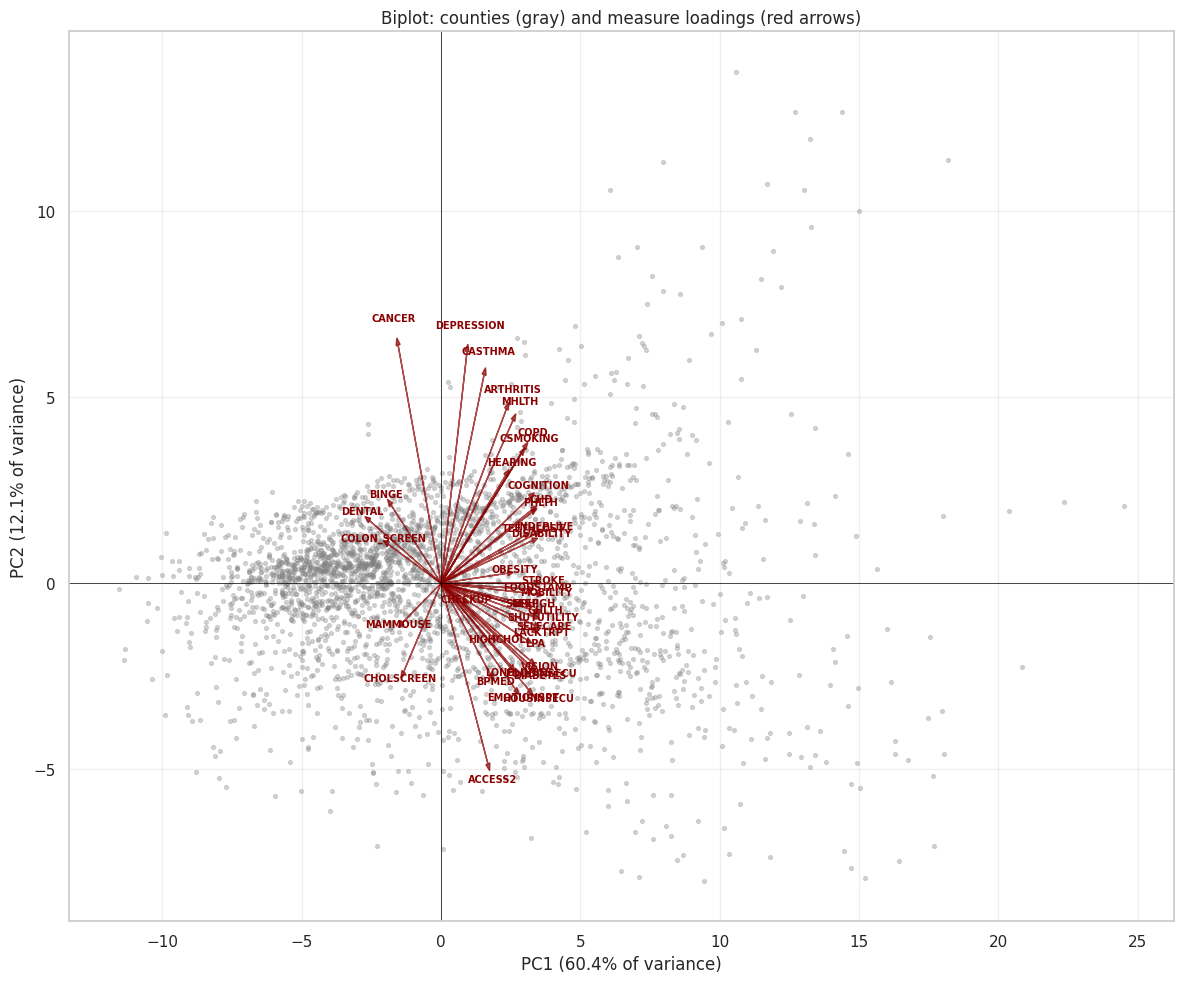

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

# Counties as background dots
ax.scatter(scores["PC1"], scores["PC2"], s=8, alpha=0.3, color="gray")

# Scale arrows
scale = max(scores["PC1"].abs().max(), scores["PC2"].abs().max()) * 0.7

# Arrow ans label for each measure
for feature in loadings.index:
    x_load = loadings.loc[feature, "PC1"] * scale
    y_load = loadings.loc[feature, "PC2"] * scale
    ax.arrow(0, 0, x_load, y_load, head_width=0.15, head_length=0.2,
             fc="darkred", ec="darkred", alpha=0.7, linewidth=1)
    ax.text(x_load * 1.1, y_load * 1.1, feature, fontsize=7,
            ha="center", color="darkred", fontweight="bold")

ax.set_xlabel(f"PC1 ({evr[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({evr[1]:.1%} of variance)")
ax.set_title("Biplot: counties (gray) and measure loadings (red arrows)")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "fig_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 28. Save PCA outputs for clustering
Notebooks 04 and 05 will run k-means and hierarchical clustering on these PC scores.

In [ ]:
# Save scores, loadings, and the standardized input
scores.to_csv(DATA_PROCESSED / "places_pca_scores.csv")
loadings.to_csv(DATA_PROCESSED / "places_pca_loadings.csv")
X.to_csv(DATA_PROCESSED / "places_X_standardized.csv")

print("Saved:")
print("  places_pca_scores.csv: county PC scores")
print("  places_pca_loadings.csv: measure loadings")
print("  places_X_standardized.csv: standardized input matrix")

Saved:
  places_pca_scores.csv: county PC scores
  places_pca_loadings.csv: measure loadings
  places_X_standardized.csv: standardized input matrix


## 29. Summary
- Ran PCA on the Algorithm 12.1-completed matrix (3,144 × 40)
- Verified equivalence with manual `np.linalg.svd`
- **PC1 = 60.4% of variance** — community health burden axis
- **3 components for 80%**, **6 components for 90%** cumulative variance
- Counties show clear regional structure in PC1-PC2 space
- Saved scores and loadings for downstream clustering

# (30) Step 04: K-Means Clustering

**Project:** Unsupervised Profiles of U.S. County-Level Community Health

## Purpose
Partition counties into K archetypes using K-means clustering. While it is possible to cluster directly on the completed health measure matrix, we deliberately cluster on the first 6 principal component scores from Step 03. This is a methodological choice, not a shortcut: the 40 original health measures are strongly correlated with one another, and K-means relies on Euclidean distance — a distance metric that double-counts shared variance when features move together. Principal components are orthogonal by construction, so each PC contributes a genuinely independent dimension of variation. Using the first 6 PCs also removes the noise captured by lower-variance components. This approach mirrors the NCI60 lab from class, where hierarchical clustering was applied to the top PC scores rather than raw gene expression values. Cluster profiles are then interpreted by mapping the resulting labels back to the original health measures, so the biological and public health meaning is preserved.

## Theoretical background
K-means minimizes within-cluster variation — the total squared Euclidean distance between each county and its assigned cluster centroid:

$$\min_{C_1, \dots, C_K} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{i, i' \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{i'j})^2$$

The algorithm (ISLR Ch. 12.4):
1. Randomly assign each observation to one of K clusters
2. Compute the centroid (mean) of each cluster
3. Reassign every observation to the nearest centroid
4. Repeat steps 2–3 until assignments no longer change

K-means converges to a **local optimum** that depends on the random starting assignments, so we run with `n_init=20` and keep the result with the lowest total WSS.

## Choosing K
Two diagnostics are used together to select the number of clusters:
- **Elbow method:** Plot WSS vs K; look for the point where the rate of improvement bends. Automated via `KneeLocator`.
- **Silhouette score:** $s_i = (b_i - a_i) / \max(a_i, b_i)$, where $a_i$ = mean intra-cluster distance, $b_i$ = mean distance to the nearest other cluster. Higher is better (max = 1).

Neither criterion is used mechanically — the final K is chosen by weighing both against interpretability.


In [ ]:
import sys
!{sys.executable} -m pip install kneed

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator  # for automatic elbow detection

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths defined globally in Cell 2 — reuse here
DATA_PROCESSED = Path("/content/processed")
FIGURES        = Path("/content/figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 31. Load PC scores and county info

We cluster on the first 6 principal component scores rather than directly on the 40 completed health measures. Three reasons motivate this choice:

1. **Correlation problem.** K-means uses Euclidean distance, which implicitly treats all features as independent. The 40 PLACES health measures are strongly correlated — obesity, physical inactivity, diabetes, and poor general health all move together. Clustering on correlated raw features over-weights the shared variance they carry and distorts the distance calculation. Principal components are orthogonal by construction, so this problem does not arise.

2. **Noise reduction.** The first 6 PCs capture approximately 90% of the variance in the completed matrix. The remaining 34 components mostly encode noise. Excluding them before clustering prevents noise from influencing the group assignments.

3. **Consistency with class lab.** This approach mirrors the NCI60 hierarchical clustering lab, where `HClust().fit(nci_scores[:,:5])` was used — clustering on PC scores rather than raw expression values.

The clustering input is a (3144, 6) matrix — one row per county, one column per PC.


In [ ]:
# Load PC scores, loadings, and county metadata
scores = pd.read_csv(DATA_PROCESSED / "places_pca_scores.csv", index_col="LocationID")
loadings = pd.read_csv(DATA_PROCESSED / "places_pca_loadings.csv", index_col=0)
completed = pd.read_csv(DATA_PROCESSED / "places_county_completed.csv", index_col="LocationID")
county_info = pd.read_csv(DATA_PROCESSED / "county_info.csv", index_col="LocationID")

# Use the first 6 PCs
N_PCS = 6
X_pca = scores.iloc[:, :N_PCS].values

print(f"Clustering input shape: {X_pca.shape}")
print(f"Using first {N_PCS} principal components (~90% variance)")

Clustering input shape: (3144, 6)
Using first 6 principal components (~90% variance)


## 32. Tune K via elbow + silhouette
We try K = 2, 3, ..., 10 and compute:
- **WSS** (within-cluster sum of squares, `inertia_` from sklearn)
- **Silhouette score**

A good K balances:
- Low WSS (compact clusters)
- High silhouette (well-separated clusters)
- Interpretability (each cluster has a story)

In [ ]:
# Try a range of K values
k_range = range(2, 11)
wss = []
silhouette = []

print("Tuning K:")
for k in k_range:
    # n_init=20
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_pca)
    wss.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    silhouette.append(sil)
    print(f"  K = {k:2d}   WSS = {km.inertia_:10.1f}   silhouette = {sil:.4f}")

# Use KneeLocator to detect the elbow automatically
kneedle = KneeLocator(list(k_range), wss, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow
print(f"\nElbow K (auto-detected): {elbow_k}")
print(f"Best silhouette K:       {list(k_range)[int(np.argmax(silhouette))]}")

Tuning K:
  K =  2   WSS =    65346.6   silhouette = 0.3784
  K =  3   WSS =    52369.2   silhouette = 0.2819
  K =  4   WSS =    46773.6   silhouette = 0.2192
  K =  5   WSS =    42117.5   silhouette = 0.2230
  K =  6   WSS =    38445.0   silhouette = 0.2281
  K =  7   WSS =    35012.8   silhouette = 0.2196
  K =  8   WSS =    32395.7   silhouette = 0.2200
  K =  9   WSS =    30103.0   silhouette = 0.2327
  K = 10   WSS =    28283.0   silhouette = 0.2245

Elbow K (auto-detected): 5
Best silhouette K:       2


## 33. Plot WSS and silhouette side by side

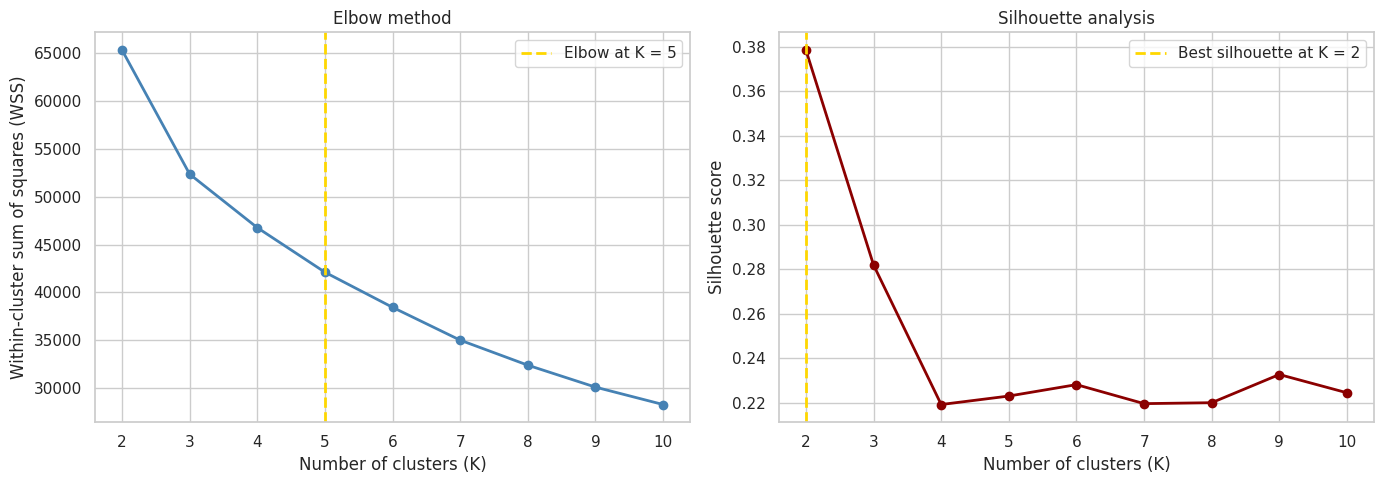

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot (WSS vs K)
axes[0].plot(list(k_range), wss, marker="o", color="steelblue", linewidth=2)
if elbow_k is not None:
    axes[0].axvline(elbow_k, color="gold", linestyle="--", linewidth=2,
                    label=f"Elbow at K = {elbow_k}")
    axes[0].legend()
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Within-cluster sum of squares (WSS)")
axes[0].set_title("Elbow method")

# silhouette vs K
axes[1].plot(list(k_range), silhouette, marker="o", color="darkred", linewidth=2)
best_sil_k = list(k_range)[int(np.argmax(silhouette))]
axes[1].axvline(best_sil_k, color="gold", linestyle="--", linewidth=2,
                label=f"Best silhouette at K = {best_sil_k}")
axes[1].legend()
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette analysis")

plt.tight_layout()
plt.savefig(FIGURES / "fig_kmeans_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## 34. Choose K and fit the final model

The two diagnostics tell different stories and must be interpreted carefully.

**Silhouette score** peaks at K = 2 (0.378), drops sharply at K = 3 (0.282), and then stabilizes in a narrow band between 0.219 and 0.233 for K = 4 through K = 10. The silhouette criterion alone would suggest K = 2, but two clusters are too coarse to be useful for public health planning — they would reduce all U.S. counties to a single binary split of "healthier" vs "less healthy" with no actionable detail.

**Elbow method** identifies K = 5 as the automated bend in the WSS curve. WSS falls from 65,347 at K = 2 to 46,774 at K = 4 — a 28% reduction — with diminishing returns beyond that point.

**K = 4 is selected** as the best balance across both diagnostics and interpretability. At K = 4 the WSS curve has bent substantially, the silhouette score has stabilized (and does not deteriorate further beyond K = 4), and four clusters produce profiles that are substantively distinct and interpretable in public health terms. K = 2 is rejected because it is too coarse; K = 5 adds a fifth cluster whose profile overlaps meaningfully with existing ones.

The moderate final silhouette of 0.2192 reflects the fact that county health patterns exist on a continuum rather than as sharply bounded groups. This is expected — a moderate silhouette does not invalidate the clustering, it simply means boundaries between profiles are gradual.


In [ ]:
# Final K
K_FINAL = 4

# Fit K-means
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Attach labels to the scores DataFrame
scores_with_clusters = scores.copy()
scores_with_clusters["Cluster"] = cluster_labels

# Final silhouette for the chosen K
final_sil = silhouette_score(X_pca, cluster_labels)
print(f"Final K-means: K = {K_FINAL}")
print(f"Final silhouette score: {final_sil:.4f}")
print(f"\nCluster sizes:")
print(scores_with_clusters["Cluster"].value_counts().sort_index())

Final K-means: K = 4
Final silhouette score: 0.2192

Cluster sizes:
Cluster
0     992
1    1148
2     751
3     253
Name: count, dtype: int64


## 35. Visualize clusters in PC1-PC2 space
We plot counties colored by cluster assignment and mark each cluster's centroid.

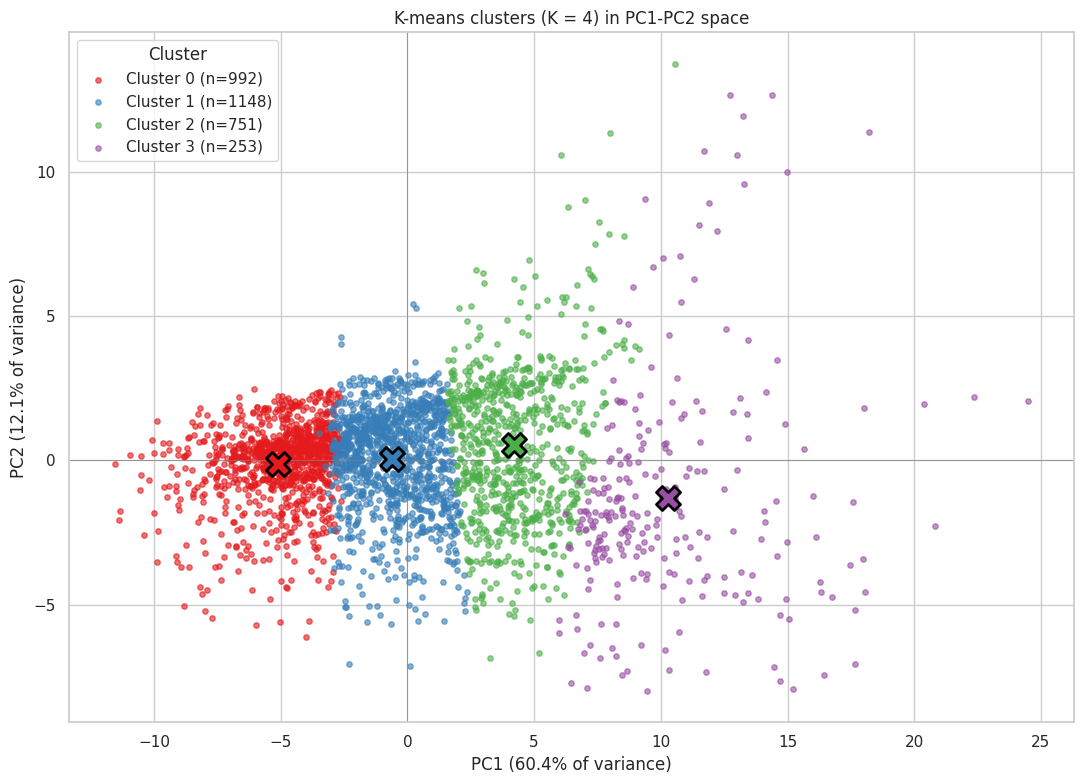

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

# One color per cluster, scattered counties
cluster_colors = sns.color_palette("Set1", n_colors=K_FINAL)
for k in range(K_FINAL):
    mask = scores_with_clusters["Cluster"] == k
    ax.scatter(scores_with_clusters.loc[mask, "PC1"],
               scores_with_clusters.loc[mask, "PC2"],
               s=15, alpha=0.6, label=f"Cluster {k} (n={mask.sum()})",
               color=cluster_colors[k])

# Mark centroids in PC1-PC2 space (project from PC space)
centroids_pca = kmeans_final.cluster_centers_
for k in range(K_FINAL):
    ax.scatter(centroids_pca[k, 0], centroids_pca[k, 1],
               s=300, marker="X", color=cluster_colors[k],
               edgecolor="black", linewidth=2, zorder=10)

ax.set_xlabel(f"PC1 ({scores.iloc[:, 0].var() / scores.var().sum():.1%} of variance)")
ax.set_ylabel(f"PC2 ({scores.iloc[:, 1].var() / scores.var().sum():.1%} of variance)")
ax.set_title(f"K-means clusters (K = {K_FINAL}) in PC1-PC2 space")
ax.legend(title="Cluster", loc="best")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES / "fig_kmeans_pc_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 36. Cluster profiles: what defines each cluster?
We compute the mean of every original health measure per cluster. This is how we **interpret** the clusters as archetypes.

In [ ]:
# Attach cluster labels to the original data
completed_with_clusters = completed.copy()
completed_with_clusters["Cluster"] = cluster_labels

# Mean of each measure per cluster
cluster_means = completed_with_clusters.groupby("Cluster").mean().round(2)
print("Cluster means (each cell = mean prevalence % of that measure in that cluster):")
cluster_means

Cluster means (each cell = mean prevalence % of that measure in that cluster):


,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CHD,CHECKUP,CHOLSCREEN,COGNITION,COLON_SCREEN,COPD,CSMOKING,DENTAL,DEPRESSION,DIABETES,DISABILITY,EMOTIONSPT,FOODINSECU,FOODSTAMP,GHLTH,HEARING,HIGHCHOL,HOUSINSECU,INDEPLIVE,LACKTRPT,LONELINESS,LPA,MAMMOUSE,MHLTH,MOBILITY,OBESITY,PHLTH,SELFCARE,SHUTUTILITY,SLEEP,STROKE,TEETHLOST,VISION
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,8.75,22.51,19.63,29.41,56.17,7.27,10.30,5.18,73.87,83.72,13.85,60.04,5.53,13.36,65.39,22.79,9.08,27.16,22.06,12.07,9.29,16.09,6.28,30.28,10.41,7.18,7.09,31.99,22.16,75.57,16.76,10.72,34.33,11.84,2.99,6.73,33.55,2.73,11.00,4.01
1,11.48,24.72,17.68,33.13,57.79,7.04,10.78,5.90,74.92,83.17,16.48,57.57,6.97,16.04,58.58,24.67,10.89,32.05,24.24,16.53,13.54,20.27,6.86,32.19,13.58,8.82,9.01,34.60,26.32,73.09,18.81,13.37,37.36,13.79,3.76,9.17,37.39,3.17,15.31,5.13
2,13.36,27.14,16.45,37.22,59.48,6.90,11.30,6.74,75.65,82.19,19.49,55.48,8.56,19.58,50.75,26.69,12.74,37.40,26.42,21.49,18.68,24.75,7.71,33.71,16.73,10.85,11.41,36.62,31.15,71.42,20.86,16.31,40.12,15.84,4.70,12.03,40.30,3.72,20.66,6.44
3,16.48,27.80,15.15,42.18,62.61,6.08,11.71,7.57,76.90,81.25,21.24,53.18,9.59,22.53,39.49,23.85,16.12,41.39,31.11,31.67,27.59,30.26,8.18,33.53,23.75,13.19,16.31,38.97,36.74,71.36,21.33,20.00,44.44,17.45,6.50,17.38,42.78,4.73,26.71,9.11


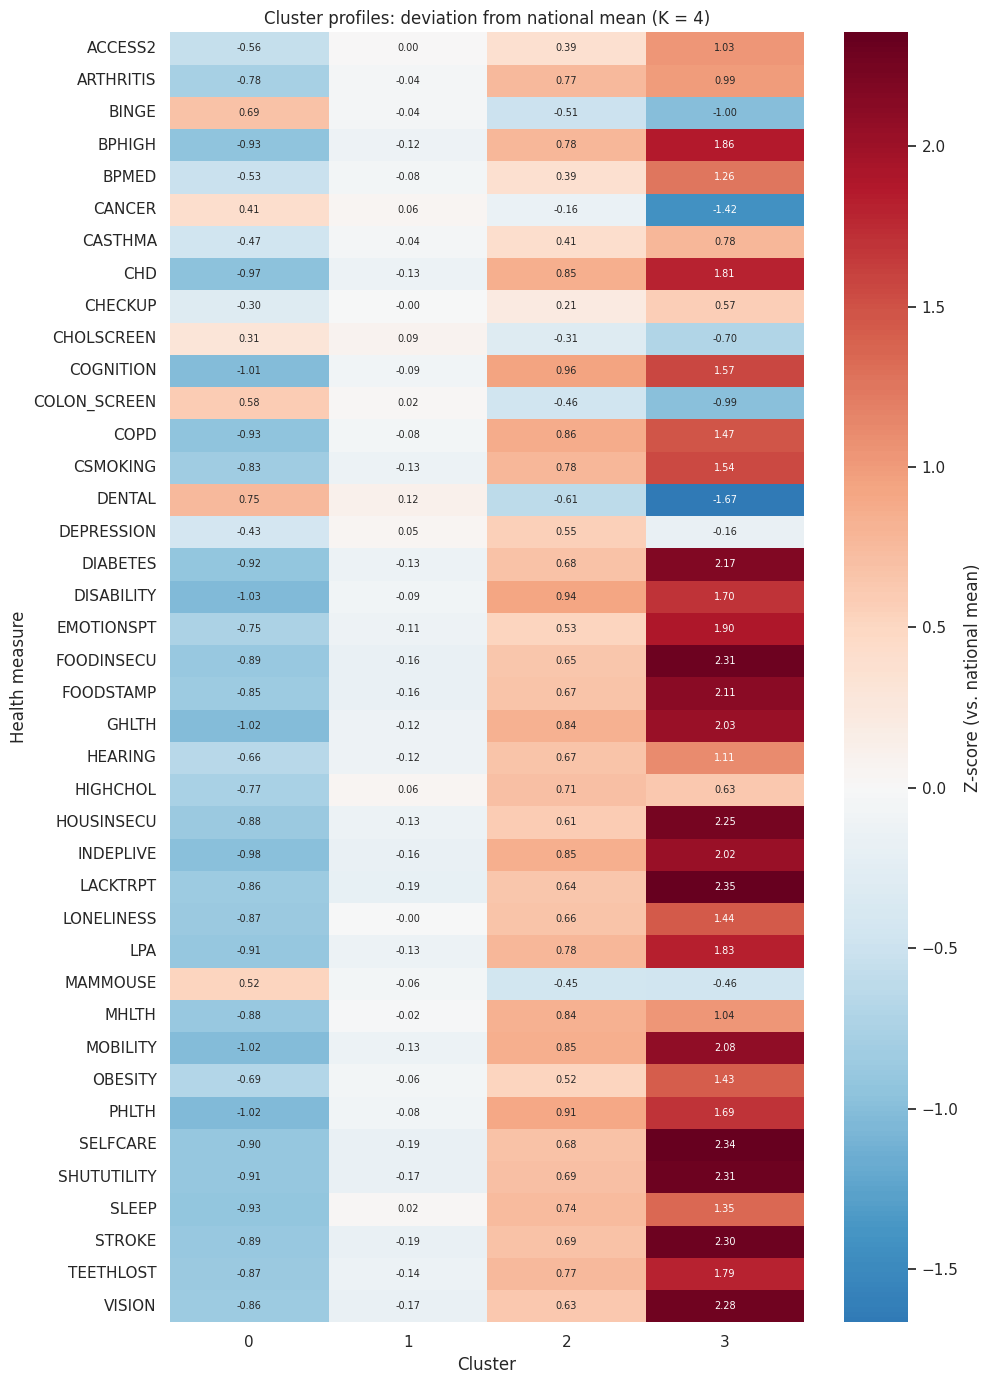

In [ ]:
# Z-score
national_mean = completed.mean()
national_std = completed.std()
cluster_zscores = (cluster_means - national_mean) / national_std

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    cluster_zscores.T,
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Z-score (vs. national mean)"},
    ax=ax,
)
ax.set_title(f"Cluster profiles: deviation from national mean (K = {K_FINAL})")
ax.set_xlabel("Cluster")
ax.set_ylabel("Health measure")
plt.tight_layout()
plt.savefig(FIGURES / "fig_kmeans_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 37. Identify defining features of each cluster
For each cluster, list the top 5 health measures that are most *above* the national average and the top 5 most *below*.

In [ ]:
# Print top features above and below national mean per cluster
for k in range(K_FINAL):
    print(f"\n--- Cluster {k} (n = {(cluster_labels == k).sum()}) ---")
    cluster_dev = cluster_zscores.loc[k].sort_values(ascending=False)
    print("Most ELEVATED measures (top 5):")
    print(cluster_dev.head(5).round(2).to_string())
    print("Most DEPRESSED measures (top 5):")
    print(cluster_dev.tail(5).round(2).to_string())


--- Cluster 0 (n = 992) ---
Most ELEVATED measures (top 5):
DENTAL          0.75
BINGE           0.69
COLON_SCREEN    0.58
MAMMOUSE        0.52
CANCER          0.41
Most DEPRESSED measures (top 5):
COGNITION    -1.01
MOBILITY     -1.02
GHLTH        -1.02
PHLTH        -1.02
DISABILITY   -1.03

--- Cluster 1 (n = 1148) ---
Most ELEVATED measures (top 5):
DENTAL        0.12
CHOLSCREEN    0.09
CANCER        0.06
HIGHCHOL      0.06
DEPRESSION    0.05
Most DEPRESSED measures (top 5):
VISION        -0.17
SHUTUTILITY   -0.17
SELFCARE      -0.19
STROKE        -0.19
LACKTRPT      -0.19

--- Cluster 2 (n = 751) ---
Most ELEVATED measures (top 5):
COGNITION     0.96
DISABILITY    0.94
PHLTH         0.91
COPD          0.86
INDEPLIVE     0.85
Most DEPRESSED measures (top 5):
CHOLSCREEN     -0.31
MAMMOUSE       -0.45
COLON_SCREEN   -0.46
BINGE          -0.51
DENTAL         -0.61

--- Cluster 3 (n = 253) ---
Most ELEVATED measures (top 5):
LACKTRPT       2.35
SELFCARE       2.34
SHUTUTILITY    2.31
F

## 38. Geographic distribution of clusters
Which states/regions do each cluster's counties tend to come from?

In [ ]:
# Cross-tab of cluster vs state
geo = completed_with_clusters.join(county_info[["StateAbbr"]])

print("Top 5 states for each cluster:")
for k in range(K_FINAL):
    states = geo[geo["Cluster"] == k]["StateAbbr"].value_counts().head(5)
    print(f"\nCluster {k}: {states.to_dict()}")

Top 5 states for each cluster:

Cluster 0: {'NE': 82, 'MN': 80, 'IA': 72, 'WI': 52, 'SD': 50}

Cluster 1: {'TX': 113, 'IN': 70, 'IL': 69, 'KS': 66, 'MI': 56}

Cluster 2: {'TX': 83, 'KY': 68, 'TN': 61, 'MO': 56, 'GA': 55}

Cluster 3: {'MS': 43, 'GA': 37, 'TX': 28, 'KY': 21, 'LA': 21}


## 39. Save outputs

In [ ]:
# Save cluster labels for the comparison notebook
labels_out = pd.DataFrame({"Cluster": cluster_labels}, index=scores.index)
labels_out.to_csv(DATA_PROCESSED / "places_kmeans_labels.csv")

# Save the cluster mean profiles for the writeup
cluster_means.to_csv(DATA_PROCESSED / "places_kmeans_cluster_means.csv")

print(f"Saved:")
print(f"  places_kmeans_labels.csv          — county-level cluster assignments")
print(f"  places_kmeans_cluster_means.csv   — mean health measure per cluster")

Saved:
  places_kmeans_labels.csv          — county-level cluster assignments
  places_kmeans_cluster_means.csv   — mean health measure per cluster


## 40. Summary

- Clustered on the **first 6 PC scores** (~90% variance) rather than raw features — a deliberate choice to remove feature correlation and noise before applying Euclidean distance
- Used `n_init=20` to reduce sensitivity to random initialization
- Tuned K = 2–10 using both WSS (elbow) and silhouette score
- **Silhouette peaks at K = 2** (0.378) but K = 2 is too coarse for public health interpretation; silhouette stabilizes from K = 4 onward
- **Elbow detected at K = 5** via `KneeLocator`
- **Selected K = 4** — the point where WSS has bent substantially, silhouette has stabilized, and clusters are substantively interpretable
- Final silhouette score at K = 4: **0.2192** (moderate, consistent with continuous health gradients across counties)

**Four county archetypes identified:**

| Cluster | n | Profile |
|---------|---|---------|
| 0 | 992 | Higher preventive care use, low chronic disease burden — concentrated in Northern Plains and Upper Midwest |
| 1 | 1,148 | Average on most measures; the modal U.S. county — spread across mid-continent states |
| 2 | 751 | High chronic disease, disability, and COPD; low screening and dental use — concentrated in Southern and border states |
| 3 | 253 | Severe social need (food insecurity, transport, utilities), high stroke, lowest preventive care use — concentrated in the Deep South |

- Saved cluster labels and mean profiles for downstream comparison with hierarchical clustering


# 41. Hierarchical Clustering


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering as HClust
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score, silhouette_score

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths defined globally in Cell 2 — reuse here
DATA_PROCESSED = Path("/content/processed")
FIGURES        = Path("/content/figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 42. Load clustering inputs

This section loads the same files produced in the earlier steps. The PCA scores, completed health matrix, county metadata, and K-means labels are all read from Google Drive so that this section can be run independently in a fresh session without rerunning earlier steps.

**Input choice — deliberate:** Hierarchical clustering is run on the same first 6 PC scores used for K-means. This is intentional for two reasons. First, the same motivation applies: the 40 raw health measures are correlated, and hierarchical clustering also uses Euclidean distance (under Ward linkage), so clustering on orthogonal PC scores is more appropriate than clustering on correlated raw features. Second, using identical inputs for both methods makes the comparison in Section 46 a fair one — any differences between K-means and hierarchical cluster assignments reflect genuine algorithmic differences, not differences in the data they were given.

Keeping K = 4 for hierarchical clustering (matching the K-means solution) also makes the cross-tabulation and Adjusted Rand Index comparison directly interpretable.


In [ ]:
# Loading the saved PCA scores, completed health matrix, county information, and K-means labels
scores = pd.read_csv(DATA_PROCESSED / "places_pca_scores.csv", index_col="LocationID")
completed = pd.read_csv(DATA_PROCESSED / "places_county_completed.csv", index_col="LocationID")
county_info = pd.read_csv(DATA_PROCESSED / "county_info.csv", index_col="LocationID")
kmeans_labels = pd.read_csv(DATA_PROCESSED / "places_kmeans_labels.csv", index_col="LocationID")

# Use the same PCA representation as the K-means section
N_PCS = 6
X_hier = scores.iloc[:, :N_PCS].copy()

# K-means labels are used later for comparison
kmeans_col = kmeans_labels.columns[0]
y_kmeans = kmeans_labels[kmeans_col].astype(int)
K_FINAL = y_kmeans.nunique()

print(f"Hierarchical clustering input shape: {X_hier.shape}")
print(f"Using first {N_PCS} principal components")
print(f"Number of clusters for comparison: K = {K_FINAL}")
print(
    "K-means cluster sizes from the previous section:")
print(y_kmeans.value_counts().sort_index())

Hierarchical clustering input shape: (3144, 6)
Using first 6 principal components
Number of clusters for comparison: K = 4
K-means cluster sizes from the previous section:
Cluster
0     992
1    1148
2     751
3     253
Name: count, dtype: int64


## 43. Compare linkage methods

Hierarchical clustering starts with each county as its own cluster and then repeatedly merges the most similar clusters. The main modeling choice is the **linkage method**, which defines how distance between two clusters is measured.

Compare four linkage methods:

| Linkage | Meaning |
|---|---|
| **Single** | Distance between the closest two counties in two clusters |
| **Complete** | Distance between the farthest two counties in two clusters |
| **Average** | Average distance between counties in two clusters |
| **Ward** | Increase in within-cluster variation after merging |

For each method, computed:

- **Silhouette score:** higher values mean counties are more clearly separated into clusters
- **Adjusted Rand Index (ARI) vs. K-means:** measures how similar the hierarchical labels are to the K-means labels
- **Smallest and largest cluster sizes:** helps identify methods that create one huge cluster and tiny outlier clusters

In [ ]:
# Computing hierarchical clustering solutions with different linkage methods
methods = ["single", "complete", "average", "ward"]
Z_dict = {}
linkage_results = []

X_values = X_hier.values

for method in methods:
    # linkage() builds the full hierarchical clustering tree
    Z = linkage(X_values, method=method, metric="euclidean")
    Z_dict[method] = Z

    # Cut the tree to the same number of clusters used by K-means
    labels = pd.Series(
        fcluster(Z, t=K_FINAL, criterion="maxclust"),
        index=X_hier.index,
        name=f"{method}_cluster"
    )

    linkage_results.append({
        "Linkage": method,
        "Silhouette score": silhouette_score(X_values, labels),
        "ARI vs K-means": adjusted_rand_score(y_kmeans, labels),
        "Smallest cluster": labels.value_counts().min(),
        "Largest cluster": labels.value_counts().max()
    })

linkage_results = pd.DataFrame(linkage_results)
linkage_results.sort_values("Silhouette score", ascending=False).round(3)

,Linkage,Silhouette score,ARI vs K-means,Smallest cluster,Largest cluster
2,average,0.460,0.066,5,2999
1,complete,0.372,0.099,20,2891
0,single,0.248,0.001,1,3140
3,ward,0.143,0.453,286,1146


The linkage comparison table helps explain why the linkage method matters. A method can have a reasonable score but still create an unhelpful clustering if almost all counties fall into one group and only a few counties are separated as outliers. For this reason, consider both the numerical metrics and the cluster-size balance.

Single linkage is especially likely to create a chaining effect, where counties are merged through a long sequence of close neighbors. Ward linkage is usually more useful for this project because it forms compact clusters, which makes the result easier to compare with K-means.

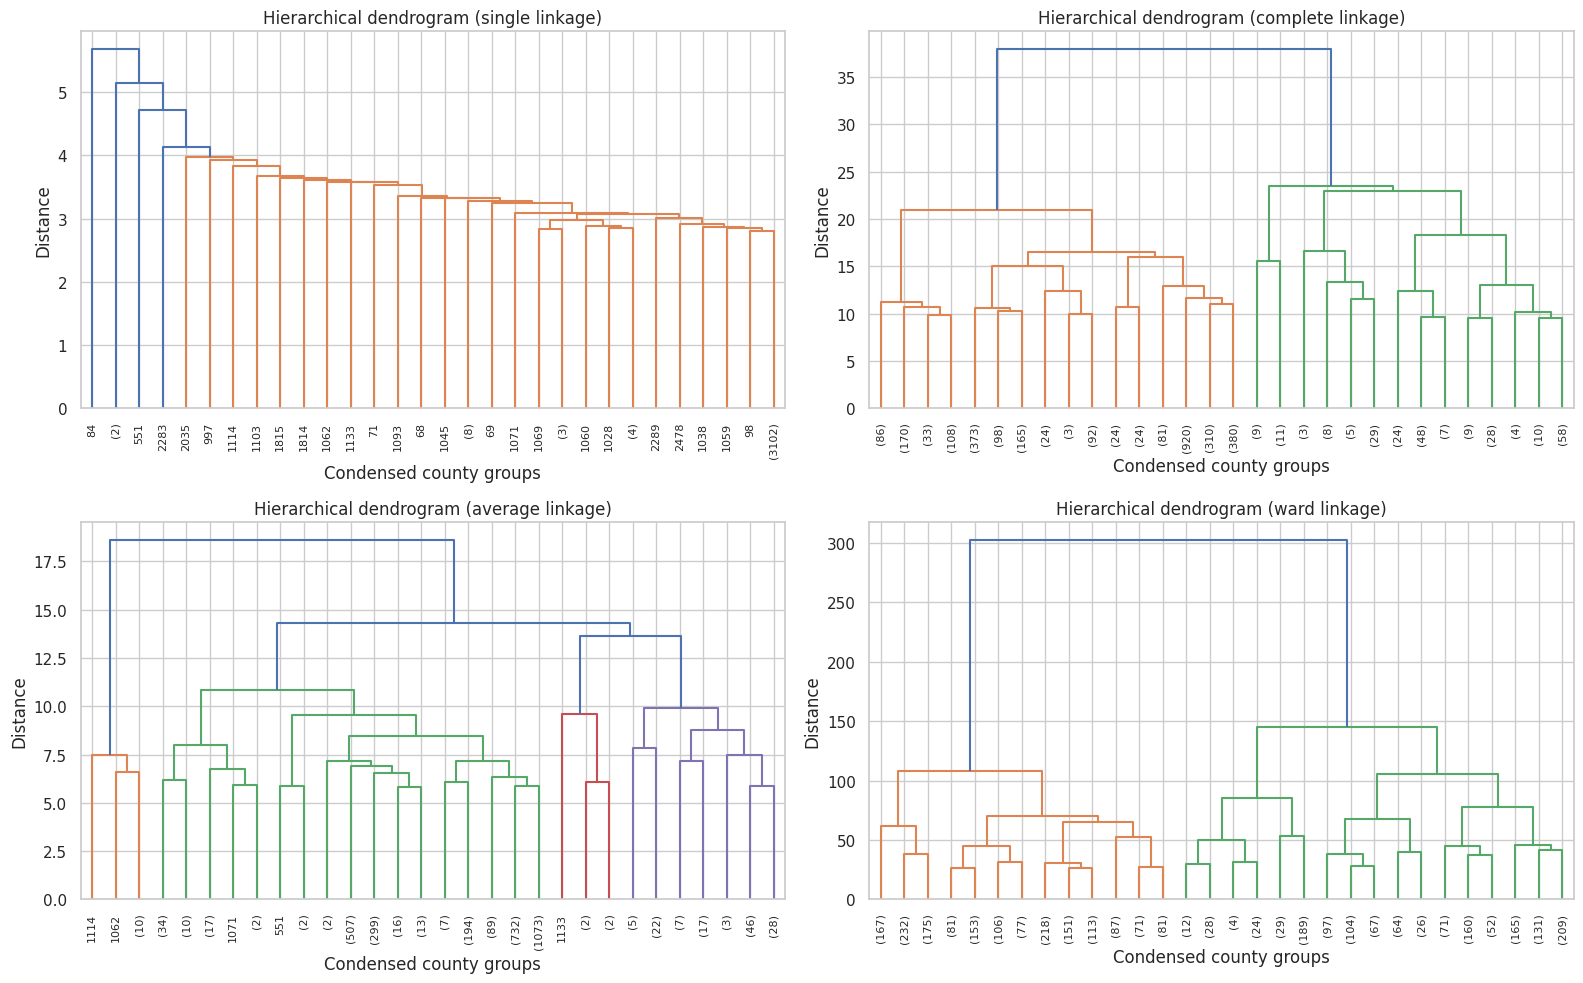

In [ ]:
# Plotting truncated dendrograms for each linkage method
# A full dendrogram with all counties would be too crowded, so this shows the last 30 merged groups.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, method in zip(axes, methods):
    dendrogram(
        Z_dict[method],
        truncate_mode="lastp",
        p=30,
        leaf_rotation=90,
        leaf_font_size=8,
        ax=ax,
        color_threshold=None
    )
    ax.set_title(f"Hierarchical dendrogram ({method} linkage)")
    ax.set_xlabel("Condensed county groups")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.savefig(FIGURES / "fig_hierarchical_dendrograms.png", dpi=150, bbox_inches="tight")
plt.show()

The dendrograms show how counties merge together as the allowed distance increases. Taller merge heights mean that very different groups are being joined. If a dendrogram has one long chain, that suggests the linkage method is not producing clean, compact county profiles. If the tree has several larger branches, that suggests a more interpretable grouping structure.

## 44. Final hierarchical clustering using Ward linkage

For the final hierarchical clustering, used **Ward linkage**. Ward linkage is appropriate here because the data are numeric, standardized PCA scores, and the goal is to form compact groups of counties with similar health profiles.

This cell cuts the Ward dendrogram into the same number of clusters used in the K-means section. Keeping the same number of clusters makes the comparison easier to interpret.

In [ ]:
# Final hierarchical clustering using Ward linkage
FINAL_LINKAGE = "ward"

hier_labels = pd.Series(
    fcluster(Z_dict[FINAL_LINKAGE], t=K_FINAL, criterion="maxclust"),
    index=X_hier.index,
    name="HierCluster"
).astype(int)

print(f"Final hierarchical linkage method: {FINAL_LINKAGE}")
print(
    "Hierarchical cluster sizes:")
print(hier_labels.value_counts().sort_index())

Final hierarchical linkage method: ward
Hierarchical cluster sizes:
HierCluster
1     574
2    1138
3     286
4    1146
Name: count, dtype: int64


The hierarchical cluster-size output tells us how many counties belong to each Ward cluster. If the clusters are not all the same size, that is not a problem. Public health profiles do not need to be evenly distributed. What matters is whether the groups are large enough to interpret and whether their health-measure profiles are meaningfully different.

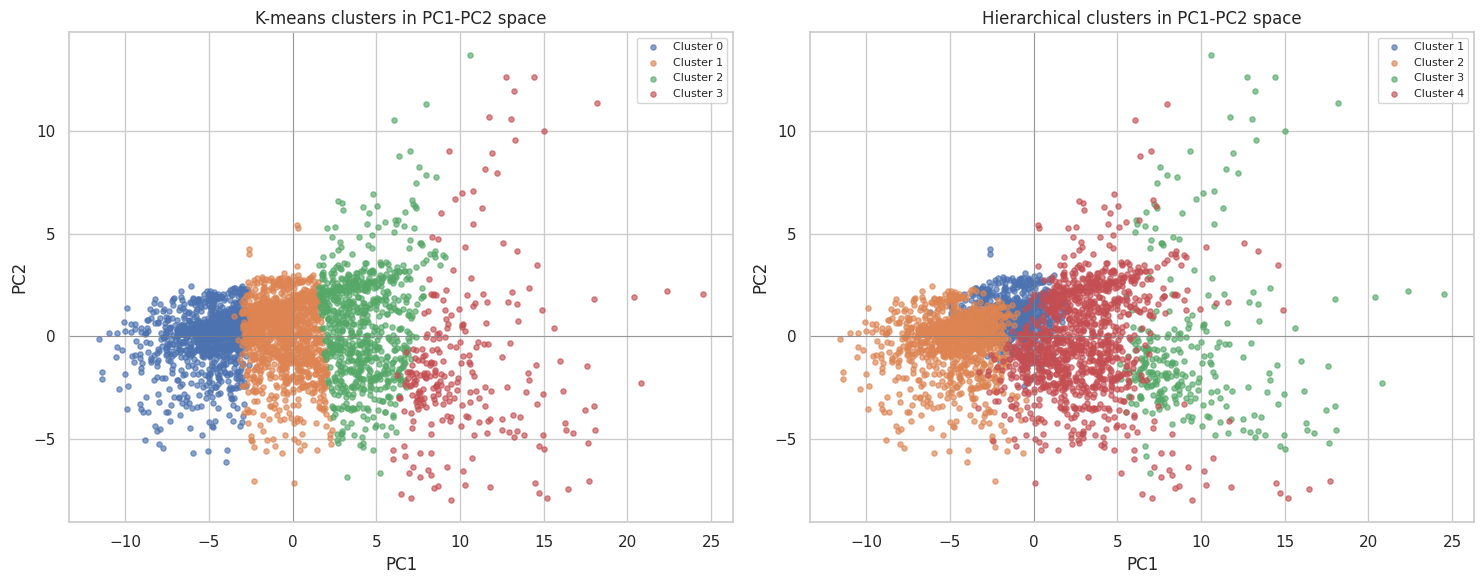

In [ ]:
# Visual comparison of K-means and hierarchical clusters in PC1-PC2 space
plot_df = scores.iloc[:, :2].copy()
plot_df["KMeansCluster"] = y_kmeans.values
plot_df["HierCluster"] = hier_labels.values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cluster in sorted(plot_df["KMeansCluster"].unique()):
    mask = plot_df["KMeansCluster"] == cluster
    axes[0].scatter(plot_df.loc[mask, "PC1"], plot_df.loc[mask, "PC2"], s=14, alpha=0.65, label=f"Cluster {cluster}")
axes[0].set_title("K-means clusters in PC1-PC2 space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].legend(fontsize=8)

for cluster in sorted(plot_df["HierCluster"].unique()):
    mask = plot_df["HierCluster"] == cluster
    axes[1].scatter(plot_df.loc[mask, "PC1"], plot_df.loc[mask, "PC2"], s=14, alpha=0.65, label=f"Cluster {cluster}")
axes[1].set_title("Hierarchical clusters in PC1-PC2 space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "fig_kmeans_vs_hierarchical_pc_space.png", dpi=150, bbox_inches="tight")
plt.show()

The side-by-side PCA plot shows where the two clustering methods agree and where they divide the PCA space differently. K-means creates clusters around centroids, while hierarchical clustering builds groups by merging nearby counties. Counties near the boundary between groups may switch clusters because they are not clearly part of only one profile.

## 45. Interpret hierarchical cluster profiles

Cluster labels only become meaningful when we connect them back to the original health measures. In this section, calculate the average health-measure profile for each hierarchical cluster and compare each cluster to the national county average.

Positive values mean the cluster is above the national county average for that measure. Negative values mean the cluster is below the national county average.

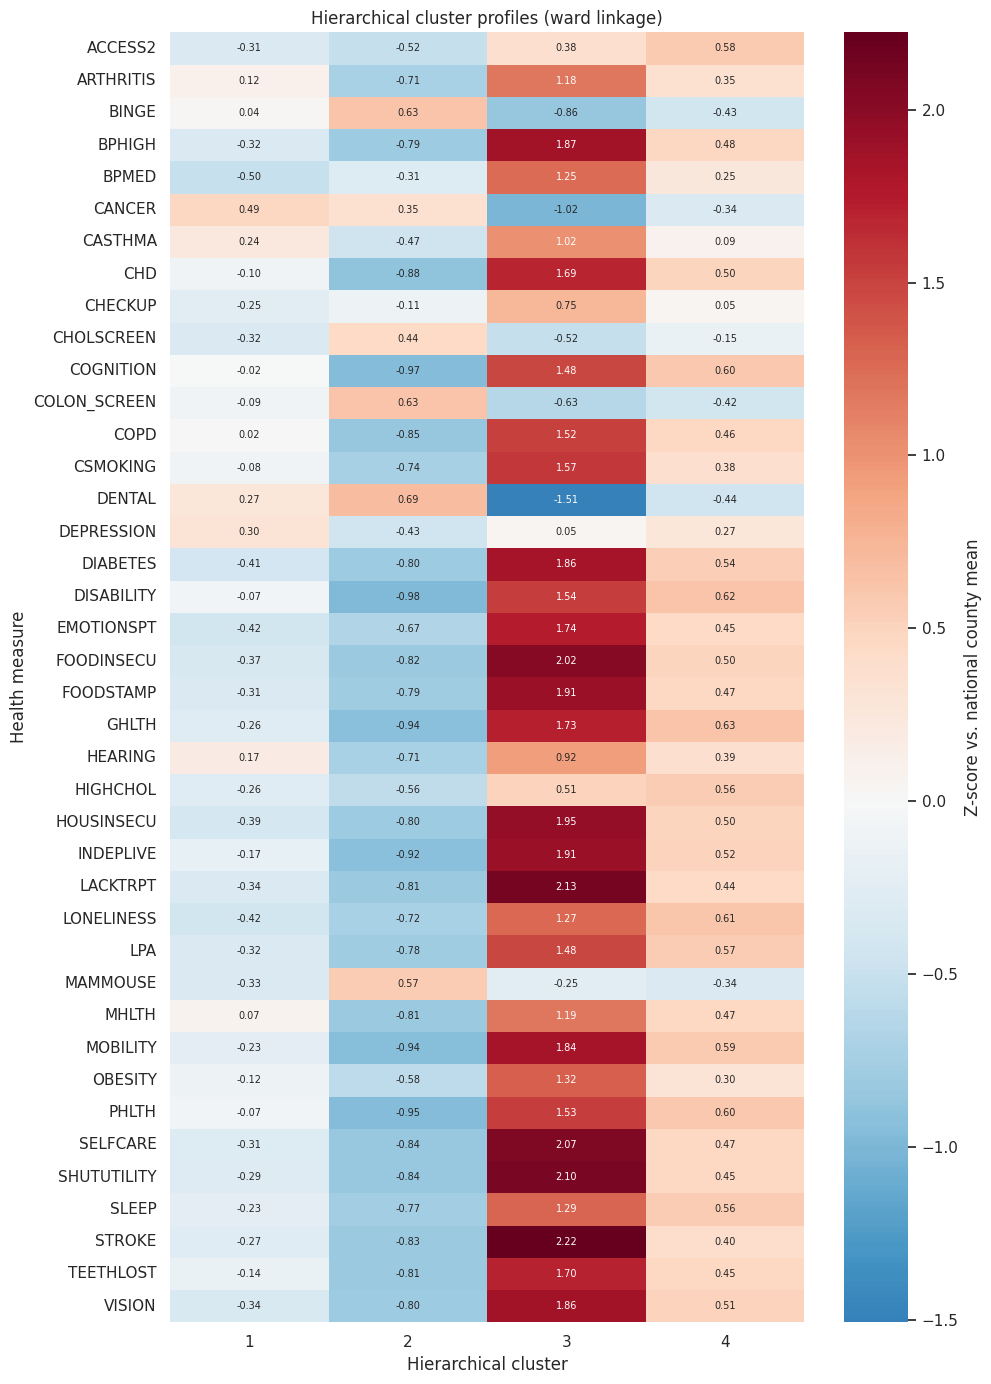

In [ ]:
# Creating hierarchical cluster profiles using the completed health measures
completed_hier = completed.copy()
completed_hier["HierCluster"] = hier_labels.values

hier_cluster_means = completed_hier.groupby("HierCluster").mean()
national_mean = completed.mean()
national_std = completed.std().replace(0, np.nan)
hier_cluster_zscores = (hier_cluster_means - national_mean) / national_std

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    hier_cluster_zscores.T,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Z-score vs. national county mean"},
    ax=ax
)
ax.set_title(f"Hierarchical cluster profiles ({FINAL_LINKAGE} linkage)")
ax.set_xlabel("Hierarchical cluster")
ax.set_ylabel("Health measure")
plt.tight_layout()
plt.savefig(FIGURES / "fig_hierarchical_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap explains what each hierarchical cluster represents. Red cells show measures that are higher than the national county average, and blue cells show measures that are lower. This is the key interpretation step: the cluster number itself is not meaningful until we describe the health pattern behind it.

In [ ]:
# Printing the most defining measures for each hierarchical cluster
for cluster in sorted(hier_labels.unique()):
    cluster_dev = hier_cluster_zscores.loc[cluster].sort_values(ascending=False)

    # Make sure county names are text before joining them.
    example_counties = county_info.loc[
        hier_labels[hier_labels == cluster].index,
        "LocationName"
    ].dropna().astype(str).head(6).tolist()

    print()
    print(f"--- Hierarchical Cluster {cluster} (n = {(hier_labels == cluster).sum()}) ---")
    print("Example counties:", ", ".join(example_counties))
    print("Most elevated measures:")
    print(cluster_dev.head(6).round(2).to_string())
    print("Most reduced measures:")
    print(cluster_dev.tail(6).round(2).to_string())


--- Hierarchical Cluster 1 (n = 574) ---
Example counties: Blount, Cullman, Lauderdale, St. Clair, Bristol Bay, Copper River
Most elevated measures:
CANCER        0.49
DEPRESSION    0.30
DENTAL        0.27
CASTHMA       0.24
HEARING       0.17
ARTHRITIS     0.12
Most reduced measures:
FOODINSECU   -0.37
HOUSINSECU   -0.39
DIABETES     -0.41
LONELINESS   -0.42
EMOTIONSPT   -0.42
BPMED        -0.50

--- Hierarchical Cluster 2 (n = 1138) ---
Example counties: Baldwin, Limestone, Madison, Shelby, Anchorage, Chugach
Most elevated measures:
DENTAL          0.69
BINGE           0.63
COLON_SCREEN    0.63
MAMMOUSE        0.57
CHOLSCREEN      0.44
CANCER          0.35
Most reduced measures:
INDEPLIVE    -0.92
GHLTH        -0.94
MOBILITY     -0.94
PHLTH        -0.95
COGNITION    -0.97
DISABILITY   -0.98

--- Hierarchical Cluster 3 (n = 286) ---
Example counties: Barbour, Bullock, Butler, Choctaw, Clarke, Conecuh
Most elevated measures:
STROKE         2.22
LACKTRPT       2.13
SHUTUTILITY    2.10


The printed output lists example counties and the measures that most define each cluster. Counties in the same cluster have similar overall health profiles across the PCA dimensions, and the profile table translates those dimensions back into public health terms.

For example, a cluster with elevated food insecurity, poor general health, disability, and physical inactivity points toward a different intervention strategy than a cluster with lower chronic disease burden but lower screening rates. This is why clustering can be useful for planning: it helps identify groups of counties that may need similar mixes of interventions.

## 46. Compare K-means and hierarchical clustering

The two clustering methods are now compared directly. K-means and hierarchical clustering do not have to produce identical labels because they use different logic:

- K-means groups counties around cluster centers.
- Hierarchical clustering builds a tree of county similarity.

If the methods mostly agree, that supports the idea that the county profiles are stable. If they disagree, that may identify counties that are between profiles.

In [ ]:
# Comparing K-means and hierarchical cluster labels
comparison_table = pd.crosstab(
    y_kmeans,
    hier_labels,
    rownames=["K-means cluster"],
    colnames=["Hierarchical cluster"]
)

ari = adjusted_rand_score(y_kmeans, hier_labels)

print(f"Adjusted Rand Index between K-means and hierarchical clustering: {ari:.3f}")
print()
print("Cross-tabulation of cluster assignments:")
comparison_table

Adjusted Rand Index between K-means and hierarchical clustering: 0.453

Cross-tabulation of cluster assignments:


Hierarchical cluster,1,2,3,4
K-means cluster,,,,
0,67,923,0,2
1,501,215,0,432
2,6,0,77,668
3,0,0,209,44


The cross-tabulation shows how counties move between the K-means clusters and the hierarchical clusters. Large counts along a few cells mean the two methods are finding similar groups. More spread across the table means the methods disagree more.

The Adjusted Rand Index summarizes this agreement in one number. A value closer to 1 means stronger agreement. A value closer to 0 means the agreement is not much better than random. In this context, partial agreement is still useful because county health patterns are continuous rather than perfectly separated.

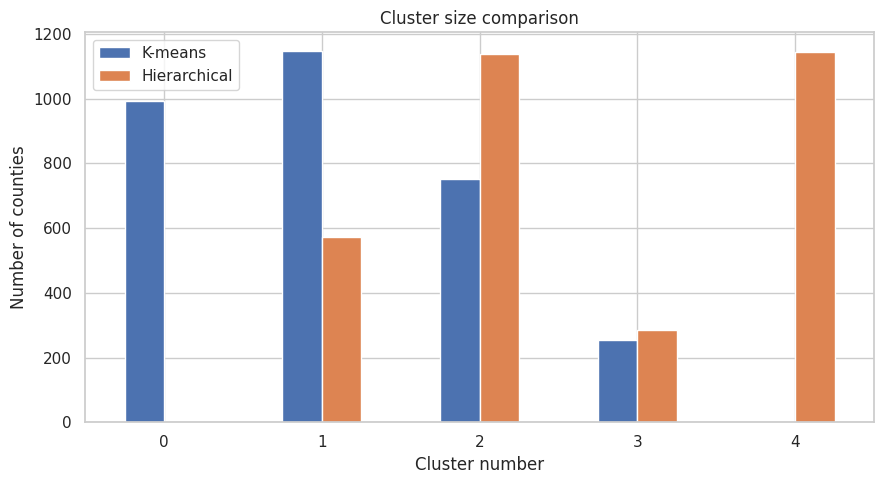

,K-means,Hierarchical
0,992,0
1,1148,574
2,751,1138
3,253,286
4,0,1146


In [ ]:
# Comparing cluster sizes from both methods
cluster_size_comparison = pd.DataFrame({
    "K-means": y_kmeans.value_counts().sort_index(),
    "Hierarchical": hier_labels.value_counts().sort_index()
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
cluster_size_comparison.plot(kind="bar", ax=ax)
ax.set_title("Cluster size comparison")
ax.set_xlabel("Cluster number")
ax.set_ylabel("Number of counties")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "fig_cluster_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

cluster_size_comparison

The size comparison checks whether either method creates very uneven groups. Uneven groups can still be valid, but if one method places nearly every county in one cluster, it is less useful for explaining different public health profiles. A reasonable spread of cluster sizes makes the groups easier to describe and compare.

In [ ]:
# Saving the hierarchical labels and cluster profiles for the final report/blog post
cluster_comparison_labels = pd.DataFrame({
    "KMeansCluster": y_kmeans.values,
    "HierCluster": hier_labels.values
}, index=X_hier.index)

cluster_comparison_labels = county_info.join(cluster_comparison_labels)

cluster_comparison_labels.to_csv(DATA_PROCESSED / "places_cluster_comparison_labels.csv")
hier_cluster_means.to_csv(DATA_PROCESSED / "places_hierarchical_cluster_means.csv")

print("Saved:")
print("  places_cluster_comparison_labels.csv")
print("  places_hierarchical_cluster_means.csv")

Saved:
  places_cluster_comparison_labels.csv
  places_hierarchical_cluster_means.csv


## 47. Summary of hierarchical clustering and comparison

The hierarchical clustering section adds a second unsupervised method for grouping counties. The main findings are:

- Several linkage methods were tested: single, complete, average, and Ward.
- The dendrograms show that linkage choice changes the tree structure.
- Ward linkage was used for the final interpretation because it creates compact groups from the standardized PCA scores.
- The hierarchical profile heatmap connects the cluster labels back to the original public health measures.
- The comparison with K-means shows how stable the county groupings are across two different clustering approaches.

Thus, the hierarchical results support the idea that counties can be grouped into interpretable community health profiles. These profiles are useful because they can guide different public health strategies for counties facing different combinations of chronic disease, disability, prevention gaps, risk behaviors, and social needs.

# 48. Conclusions

This project used unsupervised learning to explore community health patterns across U.S. counties. The analysis started with county-level health measures, reshaped the data into a wide matrix, handled missing values with matrix completion, and then used PCA/SVD to summarize the main dimensions of variation.

The PCA/SVD results show that county health patterns are not random. Many measures move together, meaning counties can be described by broader health-profile dimensions. K-means clustering used those dimensions to create practical county groups, and hierarchical clustering provided a second way to evaluate whether similar groupings appear under a different unsupervised method.

The most important interpretation is that the clusters represent different public health profiles. Some groups may have higher chronic disease, disability, physical inactivity, and social needs. Other groups may have lower overall health burden but different prevention or screening patterns. This matters because public health interventions should not be one-size-fits-all.

Grouping similar counties can help public health planners target interventions more carefully. Counties with similar profiles may benefit from similar combinations of chronic disease programs, preventive care outreach, transportation support, food access programs, mental health resources, or screening campaigns.

These clusters should be treated as exploratory evidence rather than final policy labels. A strong next step would be to combine these results with local knowledge, rural/urban information, healthcare access data, and community input before designing interventions.